# Objetivo B — Modelo Federado Para Inferencia en Guatemala

Este notebook implementa el flujo del Objetivo B del proyecto PlusTI–UVG 2025.

**Bancos etiquetados (entrenamiento):** Bolivia, Brazil
**Banco sin etiqueta (inferencia):** Guatemala

Se entrenan tres modelos candidatos y se comparan contra el feedback real de PlusTI sobre el primer 30% de Guatemala:

| Modelo | Estrategia | Precisión global (30%) |
|---|---|---|
| Centralizado | Bolivia + Brazil juntos | 98.36% |
| Federado simulado | Promedio ponderado por AUC cross-bank | 98.12% |
| **Híbrido** | **50/50 centralizado + federado** | **98.52% ✅** |

La entrega final sobre el 100% de Guatemala utiliza el **modelo híbrido**.


In [528]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

os.makedirs("resultados_objetivo_b", exist_ok=True)

print("Librerías cargadas.")
print("Carpeta resultados_objetivo_b/ lista.")

Librerías cargadas.
Carpeta resultados_objetivo_b/ lista.


## 1. Definir Rutas

In [529]:
PATHS = {
    "bolivia_limpio": "data_limpia/bolivia_limpio.csv",
    "brazil_limpio": "data_limpia/brazil_limpio.csv",
    "guatemala_limpio": "data_limpia/guatemala_limpio.csv",
    "bolivia_model": "data_limpia/bolivia_model_ready.csv",
    "brazil_model": "data_limpia/brazil_model_ready.csv",
    "guatemala_model": "data_limpia/guatemala_model_ready.csv",
}

for name, path in PATHS.items():
    print(name, "->", path, "| existe:", os.path.exists(path))

bolivia_limpio -> data_limpia/bolivia_limpio.csv | existe: True
brazil_limpio -> data_limpia/brazil_limpio.csv | existe: True
guatemala_limpio -> data_limpia/guatemala_limpio.csv | existe: True
bolivia_model -> data_limpia/bolivia_model_ready.csv | existe: True
brazil_model -> data_limpia/brazil_model_ready.csv | existe: True
guatemala_model -> data_limpia/guatemala_model_ready.csv | existe: True


## 2. Cargar Datasets

In [530]:
bolivia_limpio = pd.read_csv(PATHS["bolivia_limpio"], low_memory=False)
brazil_limpio = pd.read_csv(PATHS["brazil_limpio"], low_memory=False)
guatemala_limpio = pd.read_csv(PATHS["guatemala_limpio"], low_memory=False)

bolivia_model = pd.read_csv(PATHS["bolivia_model"], low_memory=False)
brazil_model = pd.read_csv(PATHS["brazil_model"], low_memory=False)
guatemala_model = pd.read_csv(PATHS["guatemala_model"], low_memory=False)

datasets = {
    "bolivia_limpio": bolivia_limpio,
    "brazil_limpio": brazil_limpio,
    "guatemala_limpio": guatemala_limpio,
    "bolivia_model": bolivia_model,
    "brazil_model": brazil_model,
    "guatemala_model": guatemala_model,
}

## 3. Validar Dimensiones

In [531]:
resumen_dimensiones = pd.DataFrame([
    {
        "dataset": name,
        "filas": df.shape[0],
        "columnas": df.shape[1],
    }
    for name, df in datasets.items()
])

resumen_dimensiones

,dataset,filas,columnas
0,bolivia_limpio,100003,71
1,brazil_limpio,100000,71
2,guatemala_limpio,100000,69
3,bolivia_model,100003,51
4,brazil_model,100000,52
5,guatemala_model,100000,50


## 4. Validar Targets

In [532]:
print("Bolivia target:")
print(bolivia_model["is_fraud_binary"].value_counts(dropna=False))

print("\nBrazil target:")
print(brazil_model["is_fraud_binary"].value_counts(dropna=False))

print("\nGuatemala columnas target:")
print([c for c in guatemala_model.columns if "fraud" in c.lower()])

Bolivia target:
is_fraud_binary
0    95084
1     4919
Name: count, dtype: int64

Brazil target:
is_fraud_binary
0    96795
1     3205
Name: count, dtype: int64

Guatemala columnas target:
[]


## 5. Revisar Columnas Comunes

In [533]:
cols_bolivia = set(bolivia_model.columns)
cols_brazil = set(brazil_model.columns)
cols_guatemala = set(guatemala_model.columns)

cols_comunes = sorted(cols_bolivia & cols_brazil & cols_guatemala)
cols_union = sorted(cols_bolivia | cols_brazil | cols_guatemala)

print("Columnas Bolivia:", len(cols_bolivia))
print("Columnas Brazil:", len(cols_brazil))
print("Columnas Guatemala:", len(cols_guatemala))
print("Columnas comunes:", len(cols_comunes))
print("Columnas unión:", len(cols_union))

print("\nColumnas en Brazil pero no en Bolivia:")
print(sorted(cols_brazil - cols_bolivia))

print("\nColumnas en Guatemala pero no en Bolivia:")
print(sorted(cols_guatemala - cols_bolivia))

print("\nColumnas en Bolivia pero no en Guatemala:")
print(sorted(cols_bolivia - cols_guatemala))

Columnas Bolivia: 51
Columnas Brazil: 52
Columnas Guatemala: 50
Columnas comunes: 49
Columnas unión: 52

Columnas en Brazil pero no en Bolivia:
['DE2_PAN']

Columnas en Guatemala pero no en Bolivia:
['DE2_PAN']

Columnas en Bolivia pero no en Guatemala:
['is_fraud', 'is_fraud_binary']


## 6. Definir Features Base Seguras

In [534]:
TARGET_COLS = ["is_fraud", "is_fraud_binary"]

LOCAL_OR_SENSITIVE_COLUMNS = [
    "bank_code",
    "bank_name",
    "bank_country",
    "bank_tier",
    "transaction_id",
    "client_id",
    "pan_masked",
    "pan_hash",
    "DE2_PAN",
    "DE35_track2_data_masked",
    "DE37_retrieval_reference_number",
    "DE38_authorization_code",
    "DE41_terminal_id",
    "DE42_card_acceptor_id",
    "DE102_account_id_1",
    "DE103_account_id_2",
]

feature_cols_base = sorted([
    col for col in cols_comunes
    if col not in TARGET_COLS
    and col not in LOCAL_OR_SENSITIVE_COLUMNS
])

print("Cantidad de features base:", len(feature_cols_base))
print("Features base:")
for col in feature_cols_base:
    print("-", col)

Cantidad de features base: 49
Features base:
- DE100_receiving_institution_id
- DE11_STAN
- DE123_pos_data_code
- DE12_local_time
- DE13_local_date
- DE14_expiration_date
- DE15_settlement_date
- DE18_merchant_category_code
- DE19_acquirer_country_code
- DE22_pos_entry_mode
- DE23_card_seq_number
- DE25_pos_condition_code
- DE39_response_code
- DE3_processing_code
- DE43_card_acceptor_name_location
- DE49_currency_code_transaction
- DE4_amount_transaction
- DE52_pin_data_present
- DE55_emv_data_present
- DE58_authorizing_agent_id
- DE60_pos_terminal_type
- DE61_pos_extended_data
- DE63_network_specific
- DE6_amount_cardholder_billing
- DE7_transmission_datetime
- DE9_conversion_rate_billing
- amount_diff_baseline
- amount_local
- amount_tx_currency
- amount_usd
- amount_vs_baseline
- approved
- card_brand
- channel
- client_baseline_amount
- client_home_city
- client_segment
- currency_tx_alpha
- day_of_week
- distance_from_home_km
- distance_from_home_km_was_missing
- high_amount_p95


In [535]:
X_bo_base = bolivia_model[feature_cols_base].copy()
X_br_base = brazil_model[feature_cols_base].copy()
X_gt_base = guatemala_model[feature_cols_base].copy()

print("Bolivia X base:", X_bo_base.shape)
print("Brazil X base:", X_br_base.shape)
print("Guatemala X base:", X_gt_base.shape)

assert list(X_bo_base.columns) == list(X_br_base.columns) == list(X_gt_base.columns)

print("Columnas alineadas correctamente.")

Bolivia X base: (100003, 49)
Brazil X base: (100000, 49)
Guatemala X base: (100000, 49)
Columnas alineadas correctamente.


In [536]:
resumen_features = pd.DataFrame({
    "feature": feature_cols_base,
    "dtype_bolivia": [str(X_bo_base[c].dtype) for c in feature_cols_base],
    "dtype_brazil": [str(X_br_base[c].dtype) for c in feature_cols_base],
    "dtype_guatemala": [str(X_gt_base[c].dtype) for c in feature_cols_base],
    "nulos_bolivia": [X_bo_base[c].isna().sum() for c in feature_cols_base],
    "nulos_brazil": [X_br_base[c].isna().sum() for c in feature_cols_base],
    "nulos_guatemala": [X_gt_base[c].isna().sum() for c in feature_cols_base],
    "unicos_bolivia": [X_bo_base[c].nunique(dropna=True) for c in feature_cols_base],
    "unicos_brazil": [X_br_base[c].nunique(dropna=True) for c in feature_cols_base],
    "unicos_guatemala": [X_gt_base[c].nunique(dropna=True) for c in feature_cols_base],
})

resumen_features

,feature,dtype_bolivia,dtype_brazil,dtype_guatemala,nulos_bolivia,nulos_brazil,nulos_guatemala,unicos_bolivia,unicos_brazil,unicos_guatemala
0,DE100_receiving_institution_id,float64,float64,float64,1050,1010,2983,1,1,1
1,DE11_STAN,int64,int64,int64,0,0,0,100003,100000,100000
2,DE123_pos_data_code,object,object,object,954,989,3090,8,8,8
3,DE12_local_time,int64,int64,int64,0,0,0,56346,56575,56467
4,DE13_local_date,int64,int64,int64,0,0,0,181,182,183
5,DE14_expiration_date,int64,int64,int64,0,0,0,71,70,71
6,DE15_settlement_date,float64,float64,float64,982,1025,2935,181,182,183
7,DE18_merchant_category_code,int64,int64,int64,0,0,0,26,26,26
8,DE19_acquirer_country_code,int64,int64,int64,0,0,0,8,8,8
9,DE22_pos_entry_mode,int64,int64,int64,0,0,0,7,7,7


## 7. Ingeniería De Variables

Se crean dos grupos de features nuevas sobre los tres bancos:

**7.1 Features temporales** — comportamiento del cliente en el tiempo (velocidad, frecuencia, anomalía de monto).

**7.2 Features digitales** — señales específicas del objetivo asignado: detección de fraude en plataformas digitales y redes sociales.


In [537]:
def parse_iso8583_datetime(series, year=2025):
    """
    Convierte DE7_transmission_datetime desde formato MMDDHHMMSS numérico
    hacia datetime real usando el año del dataset.
    """
    return pd.to_datetime(
        str(year) + series.astype(str).str.zfill(10),
        format="%Y%m%d%H%M%S",
        errors="coerce"
    )

In [538]:
TEMPORAL_FEATURES = [
    "time_since_last_txn_min",
    "txn_count_last_1h",
    "txn_count_last_24h",
    "amount_zscore_customer",
]


def add_temporal_features(df_limpio, train_months=(1, 2, 3, 4, 5), year=2025):
    """
    Crea features temporales por cliente usando el orden cronológico de transacciones.

    Requiere columnas:
    - DE7_transmission_datetime
    - client_id
    - amount_usd

    Retorna un DataFrame con:
    - txn_dt
    - time_since_last_txn_min
    - txn_count_last_1h
    - txn_count_last_24h
    - amount_zscore_customer
    """
    required_cols = ["DE7_transmission_datetime", "client_id", "amount_usd"]
    missing = [c for c in required_cols if c not in df_limpio.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    df_temp = df_limpio[required_cols].copy()

    df_temp["txn_dt"] = parse_iso8583_datetime(
        df_temp["DE7_transmission_datetime"],
        year=year
    )

    if df_temp["txn_dt"].isna().any():
        n_bad = df_temp["txn_dt"].isna().sum()
        raise ValueError(f"No se pudieron parsear {n_bad} timestamps.")

    df_temp["amount_usd"] = pd.to_numeric(df_temp["amount_usd"], errors="coerce")
    df_temp["amount_usd"] = df_temp["amount_usd"].fillna(df_temp["amount_usd"].median())

    sorted_df = df_temp.sort_values(["client_id", "txn_dt"]).copy()

    sorted_df["time_since_last_txn_min"] = (
        sorted_df.groupby("client_id")["txn_dt"]
        .diff()
        .dt.total_seconds()
        .div(60)
    )

    median_time = sorted_df["time_since_last_txn_min"].median()
    sorted_df["time_since_last_txn_min"] = (
        sorted_df["time_since_last_txn_min"].fillna(median_time)
    )

    counts_1h = []
    counts_24h = []

    for client_id, group in sorted_df.groupby("client_id", sort=False):
        g = group.set_index("txn_dt")

        count_1h = (
            g["amount_usd"]
            .rolling("60min", closed="left")
            .count()
            .fillna(0)
            .astype(int)
        )

        count_24h = (
            g["amount_usd"]
            .rolling("24H", closed="left")
            .count()
            .fillna(0)
            .astype(int)
        )

        counts_1h.append(pd.Series(count_1h.values, index=group.index))
        counts_24h.append(pd.Series(count_24h.values, index=group.index))

    sorted_df["txn_count_last_1h"] = pd.concat(counts_1h).sort_index()
    sorted_df["txn_count_last_24h"] = pd.concat(counts_24h).sort_index()

    is_train_time = sorted_df["txn_dt"].dt.month.isin(train_months)

    client_stats = (
        sorted_df.loc[is_train_time]
        .groupby("client_id")["amount_usd"]
        .agg(client_mean="mean", client_std="std")
    )

    sorted_df = sorted_df.join(client_stats, on="client_id")

    global_mean = sorted_df.loc[is_train_time, "amount_usd"].mean()
    global_std = sorted_df.loc[is_train_time, "amount_usd"].std()

    sorted_df["client_mean"] = sorted_df["client_mean"].fillna(global_mean)
    sorted_df["client_std"] = sorted_df["client_std"].fillna(global_std)
    sorted_df["client_std"] = sorted_df["client_std"].replace(0, global_std)

    sorted_df["amount_zscore_customer"] = (
        (sorted_df["amount_usd"] - sorted_df["client_mean"])
        / (sorted_df["client_std"] + 1e-10)
    )

    temporal_df = (
        sorted_df
        .sort_index()
        [["txn_dt"] + TEMPORAL_FEATURES]
        .copy()
    )

    return temporal_df

In [539]:
temporal_bo = add_temporal_features(bolivia_limpio)
temporal_br = add_temporal_features(brazil_limpio)
temporal_gt = add_temporal_features(guatemala_limpio)

print("Temporal Bolivia:", temporal_bo.shape)
print("Temporal Brazil:", temporal_br.shape)
print("Temporal Guatemala:", temporal_gt.shape)

display(temporal_bo.head())

Temporal Bolivia: (100003, 5)
Temporal Brazil: (100000, 5)
Temporal Guatemala: (100000, 5)


,txn_dt,time_since_last_txn_min,txn_count_last_1h,txn_count_last_24h,amount_zscore_customer
0,2025-01-01 00:01:51,6854.0500,0,0,0.0730
1,2025-01-01 00:03:55,6854.0500,0,0,2.7514
2,2025-01-01 00:04:10,6854.0500,0,0,-0.2469
3,2025-01-01 00:04:53,6854.0500,0,0,-0.6362
4,2025-01-01 00:07:56,6854.0500,0,0,-0.7176


In [540]:
for name, temporal_df in {
    "Bolivia": temporal_bo,
    "Brazil": temporal_br,
    "Guatemala": temporal_gt,
}.items():
    print(f"\n{name}")
    print("Rango fechas:", temporal_df["txn_dt"].min(), "->", temporal_df["txn_dt"].max())
    print("Nulos txn_dt:", temporal_df["txn_dt"].isna().sum())
    print("Distribución meses:")
    print(temporal_df["txn_dt"].dt.month.value_counts().sort_index())


Bolivia
Rango fechas: 2025-01-01 00:01:51 -> 2025-06-30 00:13:36
Nulos txn_dt: 0
Distribución meses:
txn_dt
1    17236
2    15663
3    17130
4    16615
5    17173
6    16186
Name: count, dtype: int64

Brazil
Rango fechas: 2025-01-01 00:02:21 -> 2025-07-01 01:57:51
Nulos txn_dt: 0
Distribución meses:
txn_dt
1    17160
2    15388
3    17314
4    16752
5    17318
6    16067
7        1
Name: count, dtype: int64

Guatemala
Rango fechas: 2025-01-01 00:06:28 -> 2025-07-01 15:22:18
Nulos txn_dt: 0
Distribución meses:
txn_dt
1    17345
2    15335
3    17265
4    16843
5    17131
6    16080
7        1
Name: count, dtype: int64


In [541]:
for name, temporal_df in {
    "Bolivia": temporal_bo,
    "Brazil": temporal_br,
    "Guatemala": temporal_gt,
}.items():
    print(f"\n{name}")
    print(temporal_df[TEMPORAL_FEATURES].isna().sum())
    display(temporal_df[TEMPORAL_FEATURES].describe().round(2))


Bolivia
time_since_last_txn_min    0
txn_count_last_1h          0
txn_count_last_24h         0
amount_zscore_customer     0
dtype: int64


,time_since_last_txn_min,txn_count_last_1h,txn_count_last_24h,amount_zscore_customer
count,100003.0000,100003.0000,100003.0000,100003.0000
mean,9798.4100,0.0600,0.2100,0.0200
std,9985.0300,0.4200,0.6200,1.0700
min,0.1700,0.0000,0.0000,-1.8400
25%,2772.6600,0.0000,0.0000,-0.6300
50%,6854.0500,0.0000,0.0000,-0.3900
75%,13456.4500,0.0000,0.0000,0.2100
max,126570.5200,7.0000,9.0000,39.4600



Brazil
time_since_last_txn_min    0
txn_count_last_1h          0
txn_count_last_24h         0
amount_zscore_customer     0
dtype: int64


,time_since_last_txn_min,txn_count_last_1h,txn_count_last_24h,amount_zscore_customer
count,100000.0000,100000.0000,100000.0000,100000.0000
mean,9802.0000,0.0100,0.1500,0.0300
std,9762.1000,0.0900,0.4000,1.1400
min,0.1000,0.0000,0.0000,-2.6300
25%,2893.4700,0.0000,0.0000,-0.5700
50%,6900.4200,0.0000,0.0000,-0.3100
75%,13442.8000,0.0000,0.0000,0.1700
max,114810.7200,2.0000,5.0000,30.0300



Guatemala
time_since_last_txn_min    0
txn_count_last_1h          0
txn_count_last_24h         0
amount_zscore_customer     0
dtype: int64


,time_since_last_txn_min,txn_count_last_1h,txn_count_last_24h,amount_zscore_customer
count,100000.0000,100000.0000,100000.0000,100000.0000
mean,12059.5200,0.0200,0.1500,0.0500
std,12219.6100,0.2600,0.4800,1.3500
min,0.0200,0.0000,0.0000,-2.8300
25%,3517.3800,0.0000,0.0000,-0.5800
50%,8430.9500,0.0000,0.0000,-0.2800
75%,16481.3100,0.0000,0.0000,0.2600
max,149597.7700,6.0000,7.0000,59.8800


In [542]:
X_bo_full = X_bo_base.join(temporal_bo[TEMPORAL_FEATURES])
X_br_full = X_br_base.join(temporal_br[TEMPORAL_FEATURES])
X_gt_full = X_gt_base.join(temporal_gt[TEMPORAL_FEATURES])

print("X Bolivia full:", X_bo_full.shape)
print("X Brazil full:", X_br_full.shape)
print("X Guatemala full:", X_gt_full.shape)

assert list(X_bo_full.columns) == list(X_br_full.columns) == list(X_gt_full.columns)

print("Features base + temporales alineadas correctamente.")

X Bolivia full: (100003, 53)
X Brazil full: (100000, 53)
X Guatemala full: (100000, 53)
Features base + temporales alineadas correctamente.


In [543]:
feature_cols_full = X_bo_full.columns.tolist()

print("Cantidad total de features:", len(feature_cols_full))
print("Features temporales agregadas:")
print(TEMPORAL_FEATURES)

Cantidad total de features: 53
Features temporales agregadas:
['time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h', 'amount_zscore_customer']


## 7.2 Ingeniería de Features — Fraude Digital y Redes Sociales

El objetivo de optimización asignado es **detectar fraudes relacionados con plataformas digitales y redes sociales**. Se construyen features específicas usando columnas ISO 8583 que capturan señales de este tipo de fraude:

| Feature | Columna origen | Lógica |
|---|---|---|
| `is_digital_merchant` | `DE18_merchant_category_code` | MCC asociados a comercio digital/software/marketplace |
| `is_card_not_present` | `DE22_pos_entry_mode` | Modos de entrada sin tarjeta física (ecommerce) |
| `is_digital_channel` | `channel` | Canal marcado como online/digital |
| `is_cross_border_digital` | `DE19_acquirer_country_code` + `is_digital_merchant` | Compra digital en país extranjero |
| `digital_no_emv` | `DE55_emv_data_present` + `is_digital_merchant` | Digital sin chip EMV (mayor riesgo) |
| `digital_fraud_risk_score` | combinación | Score compuesto de señales digitales |
| `txn_count_digital_1h` | temporal + `is_digital_merchant` | Cantidad de txn digitales del cliente en última hora |


In [544]:
# MCCs asociados a plataformas digitales, redes sociales, software y marketplaces online
# Fuente: ISO 18245 MCC reference
MCC_DIGITAL = [
    '5045',  # Computers, peripherals and software
    '5734',  # Computer software stores
    '5735',  # Record stores (streaming/digital music)
    '7372',  # Computer programming, data processing
    '7375',  # Computer information services
    '4816',  # Computer network / information services
    '5961',  # Catalog and mail-order houses (ecommerce)
    '7374',  # Computer processing and data preparation
    '5999',  # Miscellaneous retail (includes digital goods)
    '7399',  # Business services (digital platforms)
    '5969',  # Direct marketing (includes social media ads)
    '4899',  # Cable, satellite, streaming services
]

# Modos de entrada sin presencia física de tarjeta (card-not-present = ecommerce/digital)
CNP_ENTRY_MODES = ['01', '10', '81', '91', '00']

def add_digital_features(df_limpio, df_temporal):
    """
    Crea features específicas para detección de fraude digital y redes sociales.
    Requiere el DataFrame limpio original y el df_temporal con txn_dt.
    Retorna un DataFrame con las nuevas features indexado igual que df_limpio.
    """
    df = df_limpio.copy()
    df['txn_dt'] = df_temporal['txn_dt'].values

    # 1. Merchant digital
    mcc_col = df['DE18_merchant_category_code'].astype(str).str.strip()
    df['is_digital_merchant'] = mcc_col.isin(MCC_DIGITAL).astype(int)

    # 2. Card-not-present (ecommerce / sin chip físico)
    entry_col = df['DE22_pos_entry_mode'].astype(str).str.strip()
    df['is_card_not_present'] = entry_col.isin(CNP_ENTRY_MODES).astype(int)

    # 3. Canal digital
    if 'channel' in df.columns:
        ch = df['channel'].astype(str).str.lower().str.strip()
        df['is_digital_channel'] = ch.isin(['online', 'digital', 'ecommerce', 'internet', 'mobile']).astype(int)
    else:
        df['is_digital_channel'] = 0

    # 4. Cross-border + digital (fraude internacional en plataformas online)
    if 'is_international' in df.columns:
        df['is_cross_border_digital'] = (
            (df['is_international'] == True) & (df['is_digital_merchant'] == 1)
        ).astype(int)
    else:
        country_col = df['DE19_acquirer_country_code'].astype(str)
        df['is_cross_border_digital'] = (
            (country_col != country_col.mode()[0]) & (df['is_digital_merchant'] == 1)
        ).astype(int)

    # 5. Digital sin EMV (sin chip: mayor riesgo en ecommerce)
    if 'DE55_emv_data_present' in df.columns:
        emv = df['DE55_emv_data_present'].astype(str).str.lower().str.strip()
        no_emv = emv.isin(['0', 'false', 'no', 'n', 'none', 'nan', ''])
        df['digital_no_emv'] = (no_emv & (df['is_digital_merchant'] == 1)).astype(int)
    else:
        df['digital_no_emv'] = 0

    # 6. Score compuesto de riesgo digital (suma de señales)
    df['digital_fraud_risk_score'] = (
        df['is_digital_merchant'] +
        df['is_card_not_present'] +
        df['is_digital_channel'] +
        df['is_cross_border_digital'] +
        df['digital_no_emv']
    )

    # 7. Conteo de txn digitales del cliente en última hora
    df = df.sort_values('txn_dt').reset_index(drop=True)
    digital_mask = df['is_digital_merchant'] == 1
    df_digital = df[digital_mask].copy()

    counts = []
    for idx, row in df_digital.iterrows():
        if 'client_id' in df.columns:
            mask = (
                (df_digital['client_id'] == row['client_id']) &
                (df_digital['txn_dt'] >= row['txn_dt'] - pd.Timedelta(hours=1)) &
                (df_digital['txn_dt'] < row['txn_dt'])
            )
        else:
            mask = (
                (df_digital['txn_dt'] >= row['txn_dt'] - pd.Timedelta(hours=1)) &
                (df_digital['txn_dt'] < row['txn_dt'])
            )
        counts.append(mask.sum())

    df['txn_count_digital_1h'] = 0
    df.loc[digital_mask, 'txn_count_digital_1h'] = counts

    DIGITAL_FEATURES = [
        'is_digital_merchant',
        'is_card_not_present',
        'is_digital_channel',
        'is_cross_border_digital',
        'digital_no_emv',
        'digital_fraud_risk_score',
        'txn_count_digital_1h',
    ]

    return df[DIGITAL_FEATURES]

DIGITAL_FEATURES = [
    'is_digital_merchant',
    'is_card_not_present',
    'is_digital_channel',
    'is_cross_border_digital',
    'digital_no_emv',
    'digital_fraud_risk_score',
    'txn_count_digital_1h',
]

print("Función add_digital_features definida.")
print(f"Features digitales a crear: {DIGITAL_FEATURES}")

Función add_digital_features definida.
Features digitales a crear: ['is_digital_merchant', 'is_card_not_present', 'is_digital_channel', 'is_cross_border_digital', 'digital_no_emv', 'digital_fraud_risk_score', 'txn_count_digital_1h']


In [545]:
# Aplicar features digitales a los tres bancos
print("Calculando features digitales (puede tomar ~1-2 min por banco)...")

digital_bo = add_digital_features(bolivia_limpio, temporal_bo)
print("Bolivia OK:", digital_bo.shape)

digital_br = add_digital_features(brazil_limpio, temporal_br)
print("Brazil OK:", digital_br.shape)

digital_gt = add_digital_features(guatemala_limpio, temporal_gt)
print("Guatemala OK:", digital_gt.shape)

# Vista previa distribución
print("\nDistribución Bolivia:")
print(digital_bo.describe().round(3))
print("\nValores únicos channel (Bolivia):")
if 'channel' in bolivia_limpio.columns:
    print(bolivia_limpio['channel'].value_counts())

Calculando features digitales (puede tomar ~1-2 min por banco)...
Bolivia OK: (100003, 7)
Brazil OK: (100000, 7)
Guatemala OK: (100000, 7)

Distribución Bolivia:
       is_digital_merchant  is_card_not_present  is_digital_channel  \
count          100003.0000          100003.0000         100003.0000   
mean                0.0990               0.5230              0.0000   
std                 0.2990               0.4990              0.0000   
min                 0.0000               0.0000              0.0000   
25%                 0.0000               0.0000              0.0000   
50%                 0.0000               1.0000              0.0000   
75%                 0.0000               1.0000              0.0000   
max                 1.0000               1.0000              0.0000   

       is_cross_border_digital  digital_no_emv  digital_fraud_risk_score  \
count              100003.0000     100003.0000               100003.0000   
mean                    0.0220          0.0920

In [546]:
# Agregar features digitales a las matrices full
X_bo_full = X_bo_full.join(digital_bo.set_index(digital_bo.index))
X_br_full = X_br_full.join(digital_br.set_index(digital_br.index))
X_gt_full = X_gt_full.join(digital_gt.set_index(digital_gt.index))

print("X Bolivia full con features digitales:", X_bo_full.shape)
print("X Brazil full con features digitales:", X_br_full.shape)
print("X Guatemala full con features digitales:", X_gt_full.shape)

assert list(X_bo_full.columns) == list(X_br_full.columns) == list(X_gt_full.columns), \
    "Columnas desalineadas entre bancos"

print("\nFeatures digitales agregadas correctamente:")
for f in DIGITAL_FEATURES:
    print(f"  {f}: bo={X_bo_full[f].sum():,} | br={X_br_full[f].sum():,} | gt={X_gt_full[f].sum():,}")

X Bolivia full con features digitales: (100003, 60)
X Brazil full con features digitales: (100000, 60)
X Guatemala full con features digitales: (100000, 60)

Features digitales agregadas correctamente:
  is_digital_merchant: bo=9,922 | br=11,120 | gt=7,907
  is_card_not_present: bo=52,324 | br=41,880 | gt=17,824
  is_digital_channel: bo=0 | br=0 | gt=0
  is_cross_border_digital: bo=2,210 | br=1,685 | gt=367
  digital_no_emv: bo=9,176 | br=9,298 | gt=5,575
  digital_fraud_risk_score: bo=73,632 | br=63,983 | gt=31,673
  txn_count_digital_1h: bo=1,070 | br=9 | gt=369


In [547]:
# Actualizar feature_cols_full para incluir digitales
feature_cols_full = X_bo_full.columns.tolist()

print(f"Total features ahora: {len(feature_cols_full)}")
print(f"  Base:      49")
print(f"  Temporal:  4")
print(f"  Digital:   {len(DIGITAL_FEATURES)}")
print(f"  Total:     {len(feature_cols_full)}")

# Verificar que no hay nulos en las nuevas features
for f in DIGITAL_FEATURES:
    n_bo = X_bo_full[f].isna().sum()
    n_br = X_br_full[f].isna().sum()
    n_gt = X_gt_full[f].isna().sum()
    if n_bo + n_br + n_gt > 0:
        print(f"  NULOS en {f}: bo={n_bo} br={n_br} gt={n_gt}")
    else:
        print(f"  {f}: sin nulos ✓")

Total features ahora: 60
  Base:      49
  Temporal:  4
  Digital:   7
  Total:     60
  is_digital_merchant: sin nulos ✓
  is_card_not_present: sin nulos ✓
  is_digital_channel: sin nulos ✓
  is_cross_border_digital: sin nulos ✓
  digital_no_emv: sin nulos ✓
  digital_fraud_risk_score: sin nulos ✓
  txn_count_digital_1h: sin nulos ✓


## 8. Selección Final De Features Para Modelado

Se consolidan las tres capas de features construidas y se excluyen columnas que introducen ruido, fuga temporal o baja generalización entre bancos:

| Capa | Cantidad | Descripción |
|---|---|---|
| Base (ISO 8583) | 49 | Columnas comunes entre los 3 bancos, sin identificadores sensibles |
| Temporal | 4 | `time_since_last_txn_min`, `txn_count_last_1h`, `txn_count_last_24h`, `amount_zscore_customer` |
| **Digital** | **7** | **Features específicas para fraude en plataformas digitales y redes sociales** |


In [548]:
MODEL_EXCLUDE_COLUMNS = [
    # Constantes o casi sin variación entre bancos
    "DE100_receiving_institution_id",
    "DE58_authorizing_agent_id",
    "DE63_network_specific",

    # Identificador de transacción ISO8583, casi único por fila
    "DE11_STAN",

    # Fechas / timestamps crudos usados para ingeniería temporal
    "DE7_transmission_datetime",
    "DE12_local_time",
    "DE13_local_date",
    "DE14_expiration_date",
    "DE15_settlement_date",

    # Montos duplicados en formato ISO8583; se conservan variables interpretables en USD/local
    "DE4_amount_transaction",
    "DE6_amount_cardholder_billing",
]

feature_cols_model = [
    col for col in feature_cols_full
    if col not in MODEL_EXCLUDE_COLUMNS
]

print("Features full:", len(feature_cols_full))
print("Columnas excluidas:", len(MODEL_EXCLUDE_COLUMNS))
print("Features modelo:", len(feature_cols_model))

print("\nColumnas excluidas presentes:")
for col in MODEL_EXCLUDE_COLUMNS:
    if col in feature_cols_full:
        print("-", col)

print("\nFeatures finales para modelado:")
for col in feature_cols_model:
    print("-", col)

Features full: 60
Columnas excluidas: 11
Features modelo: 49

Columnas excluidas presentes:
- DE100_receiving_institution_id
- DE58_authorizing_agent_id
- DE63_network_specific
- DE11_STAN
- DE7_transmission_datetime
- DE12_local_time
- DE13_local_date
- DE14_expiration_date
- DE15_settlement_date
- DE4_amount_transaction
- DE6_amount_cardholder_billing

Features finales para modelado:
- DE123_pos_data_code
- DE18_merchant_category_code
- DE19_acquirer_country_code
- DE22_pos_entry_mode
- DE23_card_seq_number
- DE25_pos_condition_code
- DE39_response_code
- DE3_processing_code
- DE43_card_acceptor_name_location
- DE49_currency_code_transaction
- DE52_pin_data_present
- DE55_emv_data_present
- DE60_pos_terminal_type
- DE61_pos_extended_data
- DE9_conversion_rate_billing
- amount_diff_baseline
- amount_local
- amount_tx_currency
- amount_usd
- amount_vs_baseline
- approved
- card_brand
- channel
- client_baseline_amount
- client_home_city
- client_segment
- currency_tx_alpha
- day_of_wee

In [549]:
X_bo_model = X_bo_full[feature_cols_model].copy()
X_br_model = X_br_full[feature_cols_model].copy()
X_gt_model = X_gt_full[feature_cols_model].copy()

y_bo = bolivia_model["is_fraud_binary"].copy()
y_br = brazil_model["is_fraud_binary"].copy()

print("X_bo_model:", X_bo_model.shape, "| y_bo:", y_bo.shape)
print("X_br_model:", X_br_model.shape, "| y_br:", y_br.shape)
print("X_gt_model:", X_gt_model.shape)

assert list(X_bo_model.columns) == list(X_br_model.columns) == list(X_gt_model.columns)
assert len(X_bo_model) == len(y_bo)
assert len(X_br_model) == len(y_br)

print("Matrices finales alineadas correctamente.")

X_bo_model: (100003, 49) | y_bo: (100003,)
X_br_model: (100000, 49) | y_br: (100000,)
X_gt_model: (100000, 49)
Matrices finales alineadas correctamente.


In [550]:
resumen_model_features = pd.DataFrame({
    "feature": feature_cols_model,
    "dtype_bolivia": [str(X_bo_model[c].dtype) for c in feature_cols_model],
    "dtype_brazil": [str(X_br_model[c].dtype) for c in feature_cols_model],
    "dtype_guatemala": [str(X_gt_model[c].dtype) for c in feature_cols_model],
    "nulos_bolivia": [X_bo_model[c].isna().sum() for c in feature_cols_model],
    "nulos_brazil": [X_br_model[c].isna().sum() for c in feature_cols_model],
    "nulos_guatemala": [X_gt_model[c].isna().sum() for c in feature_cols_model],
    "unicos_bolivia": [X_bo_model[c].nunique(dropna=True) for c in feature_cols_model],
    "unicos_brazil": [X_br_model[c].nunique(dropna=True) for c in feature_cols_model],
    "unicos_guatemala": [X_gt_model[c].nunique(dropna=True) for c in feature_cols_model],
})

resumen_model_features

,feature,dtype_bolivia,dtype_brazil,dtype_guatemala,nulos_bolivia,nulos_brazil,nulos_guatemala,unicos_bolivia,unicos_brazil,unicos_guatemala
0,DE123_pos_data_code,object,object,object,954,989,3090,8,8,8
1,DE18_merchant_category_code,int64,int64,int64,0,0,0,26,26,26
2,DE19_acquirer_country_code,int64,int64,int64,0,0,0,8,8,8
3,DE22_pos_entry_mode,int64,int64,int64,0,0,0,7,7,7
4,DE23_card_seq_number,float64,float64,float64,1038,1006,2962,3,3,3
5,DE25_pos_condition_code,int64,int64,int64,0,0,0,4,4,4
6,DE39_response_code,int64,int64,int64,0,0,0,12,12,12
7,DE3_processing_code,int64,int64,int64,0,0,0,5,5,5
8,DE43_card_acceptor_name_location,object,object,object,0,0,0,1708,1674,1599
9,DE49_currency_code_transaction,int64,int64,int64,0,0,0,6,6,6


In [551]:
constantes_model = resumen_model_features[
    (resumen_model_features["unicos_bolivia"] <= 1) |
    (resumen_model_features["unicos_brazil"] <= 1) |
    (resumen_model_features["unicos_guatemala"] <= 1)
]

constantes_model

,feature,dtype_bolivia,dtype_brazil,dtype_guatemala,nulos_bolivia,nulos_brazil,nulos_guatemala,unicos_bolivia,unicos_brazil,unicos_guatemala
44,is_digital_channel,int64,int64,int64,0,0,0,1,1,1


## 9. Funciones Reutilizables Para Modelado Y Evaluación

Se definen funciones auxiliares para preparar datos categóricos, entrenar LightGBM y evaluar modelos bajo métricas comparables.

In [552]:
try:
    from lightgbm import LGBMClassifier
    import lightgbm as lgb

    print("LightGBM cargado correctamente.")
    print("Versión:", lgb.__version__)
except ModuleNotFoundError:
    print("LightGBM no está instalado en este entorno.")
    print("Instálalo con: pip install lightgbm")
    raise

LightGBM cargado correctamente.
Versión: 4.6.0


In [553]:
def align_categorical_columns(X_train, X_eval):
    """
    Alinea columnas categóricas entre train y evaluación.

    LightGBM puede trabajar con dtype category, pero las categorías deben
    ser consistentes entre datasets para evitar códigos distintos.
    """
    X_train_prep = X_train.copy()
    X_eval_prep = X_eval.copy()

    bool_cols = X_train_prep.select_dtypes(include="bool").columns.tolist()

    if bool_cols:
        X_train_prep[bool_cols] = X_train_prep[bool_cols].astype(int)
        X_eval_prep[bool_cols] = X_eval_prep[bool_cols].astype(int)

    cat_cols = X_train_prep.select_dtypes(include="object").columns.tolist()

    for col in cat_cols:
        X_train_prep[col] = X_train_prep[col].astype("string").fillna("DESCONOCIDO")
        X_eval_prep[col] = X_eval_prep[col].astype("string").fillna("DESCONOCIDO")

        all_categories = sorted(
            set(X_train_prep[col].unique().tolist()) |
            set(X_eval_prep[col].unique().tolist())
        )

        X_train_prep[col] = pd.Categorical(X_train_prep[col], categories=all_categories)
        X_eval_prep[col] = pd.Categorical(X_eval_prep[col], categories=all_categories)

    return X_train_prep, X_eval_prep, cat_cols

In [554]:
def evaluate_predictions(y_true, y_proba, threshold=0.5, label="modelo"):
    """
    Evalúa predicciones probabilísticas con un threshold dado.
    """
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    ratio_fp = fp / (tp + fp + 1e-10)

    try:
        auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc = np.nan

    return {
        "modelo": label,
        "threshold": round(float(threshold), 4),
        "auc_roc": round(float(auc), 4) if not np.isnan(auc) else np.nan,
        "precision_fraude": round(float(precision), 4),
        "recall_fraude": round(float(recall), 4),
        "f1_fraude": round(float(f1), 4),
        "ratio_falsos_positivos": round(float(ratio_fp), 4),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "alertas_totales": int(tp + fp),
    }

In [555]:
def sweep_thresholds(y_true, y_proba, thresholds=None, label="modelo"):
    """
    Evalúa un conjunto de thresholds para analizar el trade-off entre
    recall y falsos positivos.
    """
    if thresholds is None:
        thresholds = np.concatenate([
            np.linspace(0.001, 0.009, 9),
            np.linspace(0.01, 0.99, 99),
        ])

    rows = [
        evaluate_predictions(y_true, y_proba, threshold=t, label=label)
        for t in thresholds
    ]

    return pd.DataFrame(rows)


def find_threshold_by_recall(y_true, y_proba, target_recall=0.90, label="modelo"):
    """
    Selecciona el threshold cuyo recall está más cerca del objetivo.
    En caso de empate, elige el menor ratio de falsos positivos.
    """
    df_th = sweep_thresholds(y_true, y_proba, label=label)
    df_th["dist_recall"] = (df_th["recall_fraude"] - target_recall).abs()

    best = (
        df_th
        .sort_values(["dist_recall", "ratio_falsos_positivos"], ascending=[True, True])
        .iloc[0]
    )

    return float(best["threshold"]), df_th

In [556]:
def train_lgbm_model(X_train, y_train, X_eval=None, y_eval=None, random_state=42, spw_multiplier=1.0 ):
    """
    Entrena LightGBM con configuración base inspirada en Objetivo A.
    """
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / max(pos, 1) * spw_multiplier

    if X_eval is not None:
        X_train_prep, X_eval_prep, cat_cols = align_categorical_columns(X_train, X_eval)
    else:
        X_train_prep = X_train.copy()
        X_eval_prep = None

        bool_cols = X_train_prep.select_dtypes(include="bool").columns.tolist()
        if bool_cols:
            X_train_prep[bool_cols] = X_train_prep[bool_cols].astype(int)

        cat_cols = X_train_prep.select_dtypes(include="object").columns.tolist()
        for col in cat_cols:
            X_train_prep[col] = X_train_prep[col].astype("string").fillna("DESCONOCIDO")
            X_train_prep[col] = X_train_prep[col].astype("category")

    model = LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        verbosity=-1,
    )

    model.fit(
        X_train_prep,
        y_train,
        categorical_feature=cat_cols if cat_cols else "auto",
    )

    metadata = {
        "scale_pos_weight": scale_pos_weight,
        "cat_cols": cat_cols,
        "features": X_train_prep.columns.tolist(),
    }

    return model, X_train_prep, X_eval_prep, metadata

In [557]:
def run_training_scenario(
    scenario_name,
    X_train,
    y_train,
    X_eval,
    y_eval,
    target_recall=0.90,
    random_state=42
):
    """
    Entrena un modelo y evalúa:
    - threshold 0.5
    - threshold ajustado a recall objetivo
    """
    model, X_train_prep, X_eval_prep, metadata = train_lgbm_model(
        X_train=X_train,
        y_train=y_train,
        X_eval=X_eval,
        y_eval=y_eval,
        random_state=random_state,
    )

    y_proba = model.predict_proba(X_eval_prep)[:, 1]

    threshold_target, df_thresholds = find_threshold_by_recall(
        y_eval,
        y_proba,
        target_recall=target_recall,
        label=scenario_name,
    )

    metrics_default = evaluate_predictions(
        y_eval,
        y_proba,
        threshold=0.5,
        label=f"{scenario_name} | threshold=0.5",
    )

    metrics_target = evaluate_predictions(
        y_eval,
        y_proba,
        threshold=threshold_target,
        label=f"{scenario_name} | threshold~recall {target_recall}",
    )

    result = {
        "scenario_name": scenario_name,
        "model": model,
        "X_train_prep": X_train_prep,
        "X_eval_prep": X_eval_prep,
        "y_proba": y_proba,
        "threshold_target": threshold_target,
        "df_thresholds": df_thresholds,
        "metadata": metadata,
        "metrics": [metrics_default, metrics_target],
    }

    return result

In [558]:
print("Funciones listas para modelado:")
print("- align_categorical_columns")
print("- evaluate_predictions")
print("- sweep_thresholds")
print("- find_threshold_by_recall")
print("- train_lgbm_model")
print("- run_training_scenario")

Funciones listas para modelado:
- align_categorical_columns
- evaluate_predictions
- sweep_thresholds
- find_threshold_by_recall
- train_lgbm_model
- run_training_scenario


## 10. Validación Temporal Interna Por Banco

Se evalúa cada banco etiquetado entrenando con enero-mayo 2025 y testeando en junio 2025.
Esto simula el uso real del modelo: aprender del pasado para detectar fraude futuro.

In [559]:
bo_train_mask = temporal_bo["txn_dt"].dt.month.isin([1, 2, 3, 4, 5])
bo_test_mask = temporal_bo["txn_dt"].dt.month == 6

br_train_mask = temporal_br["txn_dt"].dt.month.isin([1, 2, 3, 4, 5])
br_test_mask = temporal_br["txn_dt"].dt.month == 6

print("Bolivia train:", bo_train_mask.sum())
print("Bolivia test:", bo_test_mask.sum())

print("\nBrazil train:", br_train_mask.sum())
print("Brazil test:", br_test_mask.sum())

print("\nBrazil filas fuera de train/test:", (~(br_train_mask | br_test_mask)).sum())

Bolivia train: 83817
Bolivia test: 16186

Brazil train: 83932
Brazil test: 16067

Brazil filas fuera de train/test: 1


In [560]:
X_bo_train_time = X_bo_model.loc[bo_train_mask].copy()
y_bo_train_time = y_bo.loc[bo_train_mask].copy()

X_bo_test_time = X_bo_model.loc[bo_test_mask].copy()
y_bo_test_time = y_bo.loc[bo_test_mask].copy()

X_br_train_time = X_br_model.loc[br_train_mask].copy()
y_br_train_time = y_br.loc[br_train_mask].copy()

X_br_test_time = X_br_model.loc[br_test_mask].copy()
y_br_test_time = y_br.loc[br_test_mask].copy()

print("Bolivia:")
print("X_train:", X_bo_train_time.shape, "| y_train:", y_bo_train_time.shape)
print("X_test: ", X_bo_test_time.shape, "| y_test: ", y_bo_test_time.shape)

print("\nBrazil:")
print("X_train:", X_br_train_time.shape, "| y_train:", y_br_train_time.shape)
print("X_test: ", X_br_test_time.shape, "| y_test: ", y_br_test_time.shape)

Bolivia:
X_train: (83817, 49) | y_train: (83817,)
X_test:  (16186, 49) | y_test:  (16186,)

Brazil:
X_train: (83932, 49) | y_train: (83932,)
X_test:  (16067, 49) | y_test:  (16067,)


In [561]:
def print_target_distribution(name, y_train, y_test):
    print(f"\n{name}")
    print("Train:")
    print(y_train.value_counts().sort_index())
    print(f"Fraude train: {y_train.mean() * 100:.2f}%")

    print("Test:")
    print(y_test.value_counts().sort_index())
    print(f"Fraude test: {y_test.mean() * 100:.2f}%")

print_target_distribution("Bolivia", y_bo_train_time, y_bo_test_time)
print_target_distribution("Brazil", y_br_train_time, y_br_test_time)


Bolivia
Train:
is_fraud_binary
0    79634
1     4183
Name: count, dtype: int64
Fraude train: 4.99%
Test:
is_fraud_binary
0    15450
1      736
Name: count, dtype: int64
Fraude test: 4.55%

Brazil
Train:
is_fraud_binary
0    81253
1     2679
Name: count, dtype: int64
Fraude train: 3.19%
Test:
is_fraud_binary
0    15542
1      525
Name: count, dtype: int64
Fraude test: 3.27%


In [562]:
bo_temporal_result = run_training_scenario(
    scenario_name="Bolivia temporal",
    X_train=X_bo_train_time,
    y_train=y_bo_train_time,
    X_eval=X_bo_test_time,
    y_eval=y_bo_test_time,
    target_recall=0.90,
    random_state=42,
)

pd.DataFrame(bo_temporal_result["metrics"])

,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,Bolivia temporal | threshold=0.5,0.5000,0.9000,0.8582,0.7649,0.8089,0.1418,563,93,173,15357,656
1,Bolivia temporal | threshold~recall 0.9,0.0100,0.9000,0.0790,0.9076,0.1454,0.9210,668,7783,68,7667,8451


In [563]:
br_temporal_result = run_training_scenario(
    scenario_name="Brazil temporal",
    X_train=X_br_train_time,
    y_train=y_br_train_time,
    X_eval=X_br_test_time,
    y_eval=y_br_test_time,
    target_recall=0.90,
    random_state=42,
)

pd.DataFrame(br_temporal_result["metrics"])

,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,Brazil temporal | threshold=0.5,0.5000,0.8602,0.7694,0.7371,0.7529,0.2306,387,116,138,15426,503
1,Brazil temporal | threshold~recall 0.9,0.0020,0.8602,0.0443,0.8971,0.0845,0.9557,471,10152,54,5390,10623


In [564]:
df_validacion_temporal = pd.DataFrame(
    bo_temporal_result["metrics"] +
    br_temporal_result["metrics"]
)

cols_resultados = [
    "modelo",
    "threshold",
    "auc_roc",
    "precision_fraude",
    "recall_fraude",
    "f1_fraude",
    "ratio_falsos_positivos",
    "TP",
    "FP",
    "FN",
    "TN",
    "alertas_totales",
]

df_validacion_temporal = df_validacion_temporal[cols_resultados]

df_validacion_temporal

,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,Bolivia temporal | threshold=0.5,0.5000,0.9000,0.8582,0.7649,0.8089,0.1418,563,93,173,15357,656
1,Bolivia temporal | threshold~recall 0.9,0.0100,0.9000,0.0790,0.9076,0.1454,0.9210,668,7783,68,7667,8451
2,Brazil temporal | threshold=0.5,0.5000,0.8602,0.7694,0.7371,0.7529,0.2306,387,116,138,15426,503
3,Brazil temporal | threshold~recall 0.9,0.0020,0.8602,0.0443,0.8971,0.0845,0.9557,471,10152,54,5390,10623


In [565]:
ruta_validacion_temporal = "resultados_objetivo_b/validacion_temporal_interna.csv"

df_validacion_temporal.to_csv(ruta_validacion_temporal, index=False)

print("Resultados guardados en:", ruta_validacion_temporal)

Resultados guardados en: resultados_objetivo_b/validacion_temporal_interna.csv


### Interpretación Validación Temporal Interna

En la validación temporal interna (entrenamiento enero–mayo, test junio 2025), **Bolivia obtuvo mejor desempeño que Brazil**.

Con threshold 0.5:
- **Bolivia**: AUC 0.8972 | Recall 76.49% | Ratio FP 15.08%
- **Brazil**: AUC 0.8605 | Recall 73.33% | Ratio FP 22.54%

Al ajustar el threshold para alcanzar ~90% de recall:
- **Bolivia**: threshold 0.01 → Recall 90.76% pero Ratio FP sube a 92.73%
- **Brazil**: threshold 0.002 → Recall 89.71% pero Ratio FP sube a 95.78%

Bolivia generaliza mejor temporalmente: mayor AUC y menor ratio de falsos positivos en ambos thresholds. El trade-off es el esperado: detectar casi todos los fraudes genera una cantidad operativamente inviable de alertas falsas.


## 11. Validación Cross-Bank

Se entrena un modelo con un banco etiquetado completo y se evalúa sobre el otro banco etiquetado completo. Esta validación estima qué tan bien generaliza el aprendizaje entre bancos de distintos países.


In [566]:
print("Bolivia completo:")
print(y_bo.value_counts().sort_index())
print(f"Fraude Bolivia: {y_bo.mean() * 100:.2f}%")

print("\nBrazil completo:")
print(y_br.value_counts().sort_index())
print(f"Fraude Brazil: {y_br.mean() * 100:.2f}%")

Bolivia completo:
is_fraud_binary
0    95084
1     4919
Name: count, dtype: int64
Fraude Bolivia: 4.92%

Brazil completo:
is_fraud_binary
0    96795
1     3205
Name: count, dtype: int64
Fraude Brazil: 3.21%


In [567]:
bo_to_br_result = run_training_scenario(
    scenario_name="Bolivia -> Brazil",
    X_train=X_bo_model,
    y_train=y_bo,
    X_eval=X_br_model,
    y_eval=y_br,
    target_recall=0.90,
    random_state=42,
)

pd.DataFrame(bo_to_br_result["metrics"])

,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,Bolivia -> Brazil | threshold=0.5,0.5000,0.7753,0.8683,0.4218,0.5678,0.1317,1352,205,1853,96590,1557
1,Bolivia -> Brazil | threshold~recall 0.9,0.0080,0.7753,0.0389,0.8961,0.0746,0.9611,2872,70933,333,25862,73805


In [568]:
br_to_bo_result = run_training_scenario(
    scenario_name="Brazil -> Bolivia",
    X_train=X_br_model,
    y_train=y_br,
    X_eval=X_bo_model,
    y_eval=y_bo,
    target_recall=0.90,
    random_state=42,
)

pd.DataFrame(br_to_bo_result["metrics"])

,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,Brazil -> Bolivia | threshold=0.5,0.5000,0.8113,0.8945,0.3257,0.4775,0.1055,1602,189,3317,94895,1791
1,Brazil -> Bolivia | threshold~recall 0.9,0.0010,0.8113,0.0629,0.9116,0.1176,0.9371,4484,66857,435,28227,71341


In [569]:
df_validacion_cross_bank = pd.DataFrame(
    bo_to_br_result["metrics"] +
    br_to_bo_result["metrics"]
)

df_validacion_cross_bank = df_validacion_cross_bank[cols_resultados]

df_validacion_cross_bank

,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,Bolivia -> Brazil | threshold=0.5,0.5000,0.7753,0.8683,0.4218,0.5678,0.1317,1352,205,1853,96590,1557
1,Bolivia -> Brazil | threshold~recall 0.9,0.0080,0.7753,0.0389,0.8961,0.0746,0.9611,2872,70933,333,25862,73805
2,Brazil -> Bolivia | threshold=0.5,0.5000,0.8113,0.8945,0.3257,0.4775,0.1055,1602,189,3317,94895,1791
3,Brazil -> Bolivia | threshold~recall 0.9,0.0010,0.8113,0.0629,0.9116,0.1176,0.9371,4484,66857,435,28227,71341


In [570]:
ruta_validacion_cross_bank = "resultados_objetivo_b/validacion_cross_bank.csv"

df_validacion_cross_bank.to_csv(ruta_validacion_cross_bank, index=False)

print("Resultados guardados en:", ruta_validacion_cross_bank)

Resultados guardados en: resultados_objetivo_b/validacion_cross_bank.csv


In [571]:
df_validacion_fase3 = pd.concat(
    [
        df_validacion_temporal.assign(tipo_validacion="temporal_interna"),
        df_validacion_cross_bank.assign(tipo_validacion="cross_bank"),
    ],
    ignore_index=True
)

df_validacion_fase3 = df_validacion_fase3[
    ["tipo_validacion"] + cols_resultados
]

df_validacion_fase3

,tipo_validacion,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,temporal_interna,Bolivia temporal | threshold=0.5,0.5000,0.9000,0.8582,0.7649,0.8089,0.1418,563,93,173,15357,656
1,temporal_interna,Bolivia temporal | threshold~recall 0.9,0.0100,0.9000,0.0790,0.9076,0.1454,0.9210,668,7783,68,7667,8451
2,temporal_interna,Brazil temporal | threshold=0.5,0.5000,0.8602,0.7694,0.7371,0.7529,0.2306,387,116,138,15426,503
3,temporal_interna,Brazil temporal | threshold~recall 0.9,0.0020,0.8602,0.0443,0.8971,0.0845,0.9557,471,10152,54,5390,10623
4,cross_bank,Bolivia -> Brazil | threshold=0.5,0.5000,0.7753,0.8683,0.4218,0.5678,0.1317,1352,205,1853,96590,1557
5,cross_bank,Bolivia -> Brazil | threshold~recall 0.9,0.0080,0.7753,0.0389,0.8961,0.0746,0.9611,2872,70933,333,25862,73805
6,cross_bank,Brazil -> Bolivia | threshold=0.5,0.5000,0.8113,0.8945,0.3257,0.4775,0.1055,1602,189,3317,94895,1791
7,cross_bank,Brazil -> Bolivia | threshold~recall 0.9,0.0010,0.8113,0.0629,0.9116,0.1176,0.9371,4484,66857,435,28227,71341


In [572]:
ruta_validacion_fase3 = "resultados_objetivo_b/resumen_validacion_fase3.csv"

df_validacion_fase3.to_csv(ruta_validacion_fase3, index=False)

print("Resumen Fase 3 guardado en:", ruta_validacion_fase3)

Resumen Fase 3 guardado en: resultados_objetivo_b/resumen_validacion_fase3.csv


## 12. Fase 4 - Modelo 1: Centralizado Bolivia + Brazil

Se concatenan Bolivia y Brazil completos para entrenar un único LightGBM. Es el baseline federado: un solo modelo con datos de dos bancos distintos, aplicado luego a Guatemala.


In [573]:
# Concatenar Bolivia + Brazil
X_central = pd.concat([X_bo_model, X_br_model], ignore_index=True)
y_central = pd.concat([y_bo, y_br], ignore_index=True)

print("X centralizado:", X_central.shape)
print("y centralizado:", y_central.shape)
print(f"\nFraude total: {y_central.mean() * 100:.2f}%")
print(f"  Bolivia: {y_bo.mean() * 100:.2f}%")
print(f"  Brazil:  {y_br.mean() * 100:.2f}%")

X centralizado: (200003, 49)
y centralizado: (200003,)

Fraude total: 4.06%
  Bolivia: 4.92%
  Brazil:  3.21%


### 12.1 Validación del Modelo Centralizado

Se evalúa el modelo centralizado (Bolivia + Brazil) sobre cada banco por separado.

**Resultados obtenidos:**
- **Centralizado → Bolivia**: AUC 0.9990 | Recall (th=0.5) 99.11% | Ratio FP 19.91% | Recall (th=0.74) 89.71% | Ratio FP 5.38%
- **Centralizado → Brazil**: AUC 0.9989 | Recall (th=0.5) ~99% | Recall (th=0.66) ~90%

El modelo centralizado supera significativamente a los modelos individuales en validación cruzada, con AUC cercano a 1.0 en ambos bancos. Esto confirma que combinar Bolivia + Brazil aporta más señal que entrenar con un solo banco.


In [574]:
# Validar modelo centralizado sobre Bolivia y Brazil por separado
central_vs_bo = run_training_scenario(
    scenario_name="Centralizado -> Bolivia",
    X_train=X_central,
    y_train=y_central,
    X_eval=X_bo_model,
    y_eval=y_bo,
    target_recall=0.90,
    random_state=42,
)

central_vs_br = run_training_scenario(
    scenario_name="Centralizado -> Brazil",
    X_train=X_central,
    y_train=y_central,
    X_eval=X_br_model,
    y_eval=y_br,
    target_recall=0.90,
    random_state=42,
)

df_validacion_central = pd.DataFrame(
    central_vs_bo["metrics"] +
    central_vs_br["metrics"]
)[cols_resultados]

df_validacion_central

,modelo,threshold,auc_roc,precision_fraude,recall_fraude,f1_fraude,ratio_falsos_positivos,TP,FP,FN,TN,alertas_totales
0,Centralizado -> Bolivia | threshold=0.5,0.5000,0.9989,0.7969,0.9892,0.8827,0.2031,4866,1240,53,93844,6106
1,Centralizado -> Bolivia | threshold~recall 0.9,0.7400,0.9989,0.9446,0.8973,0.9204,0.0554,4414,259,505,94825,4673
2,Centralizado -> Brazil | threshold=0.5,0.5000,0.9989,0.7947,0.9700,0.8737,0.2053,3109,803,96,95992,3912
3,Centralizado -> Brazil | threshold~recall 0.9,0.6600,0.9989,0.9299,0.9020,0.9157,0.0701,2891,218,314,96577,3109


In [575]:
# Guardar validación del modelo centralizado
df_validacion_central.to_csv(
    "resultados_objetivo_b/validacion_modelo_centralizado.csv",
    index=False
)
print("Validación centralizado guardada.")

Validación centralizado guardada.


### 12.2 Entrenar Modelo Centralizado Final (Bolivia + Brazil Completos)

Confirmada la validación, se entrena el modelo final sobre el 100% de Bolivia + Brazil sin eval set. Este es el modelo que se aplica directamente a Guatemala para generar inferencias.


In [576]:
# Entrenamiento final con Bolivia + Brazil completos (sin eval set, sin leakage)
modelo_central_final, X_central_prep, _, metadata_central = train_lgbm_model(
    X_train=X_central,
    y_train=y_central,
    X_eval=None,
    random_state=42,
    spw_multiplier=1.0
)

print("Modelo centralizado entrenado.")
print(f"  scale_pos_weight: {metadata_central['scale_pos_weight']:.2f}")
print(f"  Features usadas: {len(metadata_central['features'])}")
print(f"  Columnas categóricas: {len(metadata_central['cat_cols'])}")

Modelo centralizado entrenado.
  scale_pos_weight: 23.62
  Features usadas: 49
  Columnas categóricas: 12


## 13. Fase 4 - Modelo 2: Federado Simulado

Se entrenan dos modelos LightGBM por separado, uno con Bolivia y otro con Brazil. Las probabilidades sobre Guatemala se combinan con promedio ponderado según el AUC cross-bank de cada banco:

- **Peso Bolivia**: 0.4934 (AUC cross-bank: 0.7779)
- **Peso Brazil**: 0.5066 (AUC cross-bank: 0.7988)

Brazil recibe ligeramente más peso porque generalizó mejor al evaluar sobre Bolivia.


In [577]:
# Entrenar modelos individuales (sin eval, para inferencia directa)
modelo_bo_final, X_bo_prep_final, _, metadata_bo = train_lgbm_model(
    X_train=X_bo_model,
    y_train=y_bo,
    X_eval=None,
    random_state=42,
    spw_multiplier=1.0
)

modelo_br_final, X_br_prep_final, _, metadata_br = train_lgbm_model(
    X_train=X_br_model,
    y_train=y_br,
    X_eval=None,
    random_state=42,
    spw_multiplier=1.0
)

print("Modelos individuales entrenados.")
print(f"  Bolivia  - scale_pos_weight: {metadata_bo['scale_pos_weight']:.2f}")
print(f"  Brazil   - scale_pos_weight: {metadata_br['scale_pos_weight']:.2f}")

Modelos individuales entrenados.
  Bolivia  - scale_pos_weight: 19.33
  Brazil   - scale_pos_weight: 30.20


In [578]:
# Pesos federados basados en AUC cross-bank (de la Fase 3)
# Bolivia -> Brazil AUC: 0.7779
# Brazil  -> Bolivia AUC: 0.7988
# El que mejor generaliza al otro recibe más peso

auc_bo_cross = 0.7779   # Bolivia entrenado, evaluado en Brazil
auc_br_cross = 0.7988   # Brazil entrenado, evaluado en Bolivia

peso_bo = auc_bo_cross / (auc_bo_cross + auc_br_cross)
peso_br = auc_br_cross / (auc_bo_cross + auc_br_cross)

print(f"Peso Bolivia:  {peso_bo:.4f}")
print(f"Peso Brazil:   {peso_br:.4f}")
print(f"Suma pesos:    {peso_bo + peso_br:.4f}")

Peso Bolivia:  0.4934
Peso Brazil:   0.5066
Suma pesos:    1.0000


## 14. Fase 5 - Preparar X_gt para inferencia

Se prepara Guatemala alineando las categorías contra el set de entrenamiento
de cada modelo antes de predecir.

In [579]:
# Preparar Guatemala para cada modelo
# Modelo centralizado
X_central_gt_prep, X_gt_central_aligned, _ = align_categorical_columns(
    X_central, X_gt_model
)

# Modelo Bolivia individual
X_bo_gt_prep, X_gt_bo_aligned, _ = align_categorical_columns(
    X_bo_model, X_gt_model
)

# Modelo Brazil individual
X_br_gt_prep, X_gt_br_aligned, _ = align_categorical_columns(
    X_br_model, X_gt_model
)

print("Guatemala preparada para los 3 modelos.")
print(f"  Shape Guatemala: {X_gt_central_aligned.shape}")

Guatemala preparada para los 3 modelos.
  Shape Guatemala: (100000, 49)


## 14. Fase 5 - Preparar Guatemala Para Inferencia

Se alinean las columnas categóricas de Guatemala contra el set de entrenamiento de cada modelo antes de predecir, garantizando que los encodings sean consistentes.


In [580]:
# Probabilidades de cada modelo sobre Guatemala completa
prob_gt_central = modelo_central_final.predict_proba(X_gt_central_aligned)[:, 1]
prob_gt_bo      = modelo_bo_final.predict_proba(X_gt_bo_aligned)[:, 1]
prob_gt_br      = modelo_br_final.predict_proba(X_gt_br_aligned)[:, 1]

# Federado simulado: promedio ponderado
prob_gt_federado = peso_bo * prob_gt_bo + peso_br * prob_gt_br

print("Probabilidades generadas.")
print(f"  prob_gt_central  - min: {prob_gt_central.min():.4f} | max: {prob_gt_central.max():.4f} | mean: {prob_gt_central.mean():.4f}")
print(f"  prob_gt_bo       - min: {prob_gt_bo.min():.4f}      | max: {prob_gt_bo.max():.4f}      | mean: {prob_gt_bo.mean():.4f}")
print(f"  prob_gt_br       - min: {prob_gt_br.min():.4f}      | max: {prob_gt_br.max():.4f}      | mean: {prob_gt_br.mean():.4f}")
print(f"  prob_gt_federado - min: {prob_gt_federado.min():.4f} | max: {prob_gt_federado.max():.4f} | mean: {prob_gt_federado.mean():.4f}")

Probabilidades generadas.
  prob_gt_central  - min: 0.0000 | max: 0.9999 | mean: 0.0666
  prob_gt_bo       - min: 0.0000      | max: 1.0000      | mean: 0.0297
  prob_gt_br       - min: 0.0000      | max: 1.0000      | mean: 0.0276
  prob_gt_federado - min: 0.0000 | max: 0.9999 | mean: 0.0286


### 14.1.1 Modelo 3 - Ensemble Híbrido: Centralizado + Federado

Se promedian en partes iguales (50/50) las probabilidades del modelo centralizado y del federado simulado:

- **Centralizado**: Bolivia + Brazil entrenados juntos, captura patrones comunes entre bancos.
- **Federado simulado**: promedio ponderado BO 49.3% + BR 50.7%, preserva la heterogeneidad entre instituciones.

El híbrido atenúa el sesgo de cada fuente sin requerir un nuevo modelo ni introducir variables locales.


In [581]:
# Modelo 3 - Ensemble Híbrido: promedio simple (50/50) de centralizado y federado
prob_gt_hibrido = 0.5 * prob_gt_central + 0.5 * prob_gt_federado

# Validaciones
assert len(prob_gt_hibrido) == 100_000, "prob_gt_hibrido debe tener 100,000 valores"
assert not pd.isnull(prob_gt_hibrido).any(), "prob_gt_hibrido contiene nulos"

print("prob_gt_hibrido generada correctamente.")
print(f"  filas : {len(prob_gt_hibrido):,}")
print(f"  min   : {prob_gt_hibrido.min():.4f}")
print(f"  max   : {prob_gt_hibrido.max():.4f}")
print(f"  mean  : {prob_gt_hibrido.mean():.4f}")
print(f"  nulos : {pd.isnull(prob_gt_hibrido).sum()}")


prob_gt_hibrido generada correctamente.
  filas : 100,000
  min   : 0.0001
  max   : 0.9999
  mean  : 0.0476
  nulos : 0


### 14.2 Thresholds Utilizados Por Modelo

| Modelo | Threshold | Criterio |
|---|---|---|
| Centralizado | 0.74 | Recall ~90% en validación cross-bank |
| Federado simulado | 0.50 | Corte neutro; thresholds individuales generaban >60% fraude |
| **Híbrido** | **0.50** | Misma lógica que el federado; probabilidades combinadas ya calibradas |

Bolivia solo y Brazil solo se descartaron como modelos de inferencia porque sus thresholds originales (~0.01 y ~0.001) producían predicciones de fraude de 37% y 83% respectivamente, valores operativamente inviables.


In [582]:
# Thresholds de referencia provenientes de validación cross-bank (Fase 3)
# Ajustar estos valores si la validación del modelo centralizado devuelve distintos

THRESHOLD_CENTRAL  = central_vs_bo["threshold_target"]   # viene del run_training_scenario
THRESHOLD_FEDERADO = 0.37   
THRESHOLD_HIBRIDO  = 0.37     # preliminar: ajustar según feedback de PlusTI sobre el 30%

print(f"Threshold centralizado (recall~0.9 en cross-bank): {THRESHOLD_CENTRAL:.4f}")
print(f"Threshold federado ponderado:                       {THRESHOLD_FEDERADO:.4f}")
print(f"Threshold híbrido (preliminar):                     {THRESHOLD_HIBRIDO:.4f}")


Threshold centralizado (recall~0.9 en cross-bank): 0.7400
Threshold federado ponderado:                       0.3700
Threshold híbrido (preliminar):                     0.3700


### 14.3 Comparativo de Predicciones en Guatemala (100%)

Se compara la distribución de alertas generadas por cada modelo sobre las 100,000 transacciones de Guatemala:


In [583]:
# Comparar cuántas alertas genera cada modelo sobre Guatemala completa
def resumen_inferencia(nombre, prob, threshold):
    pred = (prob >= threshold).astype(int)
    n_fraude = pred.sum()
    n_total  = len(pred)
    return {
        "modelo": nombre,
        "threshold": round(threshold, 4),
        "predicciones_fraude": int(n_fraude),
        "predicciones_legitimas": int(n_total - n_fraude),
        "pct_fraude": round(n_fraude / n_total * 100, 2),
    }

resumen_gt = pd.DataFrame([
    resumen_inferencia("Centralizado",    prob_gt_central,  THRESHOLD_CENTRAL),
    resumen_inferencia("Federado",        prob_gt_federado, THRESHOLD_FEDERADO),
    resumen_inferencia("Híbrido",         prob_gt_hibrido,  THRESHOLD_HIBRIDO),
    resumen_inferencia("Bolivia solo",    prob_gt_bo,       bo_to_br_result["threshold_target"]),
    resumen_inferencia("Brazil solo",     prob_gt_br,       br_to_bo_result["threshold_target"]),
])

resumen_gt


,modelo,threshold,predicciones_fraude,predicciones_legitimas,pct_fraude
0,Centralizado,0.7400,2955,97045,2.9600
1,Federado,0.3700,2984,97016,2.9800
2,Híbrido,0.3700,3197,96803,3.2000
3,Bolivia solo,0.0080,25062,74938,25.0600
4,Brazil solo,0.0010,79311,20689,79.3100


### 14.4 Generar Archivos Excel — Primer 30% de Guatemala

Se generan tres archivos preliminares sobre las primeras 30,000 transacciones para envío a PlusTI:
- **Centralizado** (th=0.74): 809 fraudes predichos (2.70%)
- **Federado** (th=0.50): 730 fraudes predichos (2.43%)
- **Híbrido** (th=0.50): predicciones combinadas 50/50


In [584]:
# Primer 30% = primeras 30,000 filas en orden original del CSV
N_30PCT = 30_000

pred_central_bool  = (prob_gt_central  >= THRESHOLD_CENTRAL).astype(bool)
pred_federado_bool = (prob_gt_federado >= THRESHOLD_FEDERADO).astype(bool)
pred_hibrido_bool  = (prob_gt_hibrido  >= THRESHOLD_HIBRIDO).astype(bool)

# Validaciones antes de exportar
assert len(pred_central_bool)  == 100_000, "Guatemala debe tener 100,000 filas"
assert len(pred_federado_bool) == 100_000, "Guatemala debe tener 100,000 filas"
assert len(pred_hibrido_bool)  == 100_000, "Guatemala debe tener 100,000 filas"

print(f"Fraudes en 30% - Centralizado: {pred_central_bool[:N_30PCT].sum()}")
print(f"Fraudes en 30% - Federado:     {pred_federado_bool[:N_30PCT].sum()}")
print(f"Fraudes en 30% - Híbrido:      {pred_hibrido_bool[:N_30PCT].sum()}")


Fraudes en 30% - Centralizado: 856
Fraudes en 30% - Federado:     862
Fraudes en 30% - Híbrido:      931


In [585]:
import openpyxl

# --- Entrega 1: Modelo centralizado ---
df_30pct_central = pd.DataFrame({
    "is_fraud": pred_central_bool[:N_30PCT]
})
df_30pct_central["is_fraud"] = df_30pct_central["is_fraud"].map({True: "True", False: "False"})
ruta_30pct_central = "resultados_objetivo_b/inferencia_30pct_centralizado.xlsx"
df_30pct_central.to_excel(ruta_30pct_central, index=False)

# --- Entrega 2: Modelo federado ---
df_30pct_federado = pd.DataFrame({
    "is_fraud": pred_federado_bool[:N_30PCT]
})
df_30pct_federado["is_fraud"] = df_30pct_federado["is_fraud"].map({True: "True", False: "False"})
ruta_30pct_federado = "resultados_objetivo_b/inferencia_30pct_federado.xlsx"
df_30pct_federado.to_excel(ruta_30pct_federado, index=False)

# --- Entrega 3: Modelo híbrido ---
df_30pct_hibrido = pd.DataFrame({
    "is_fraud": pred_hibrido_bool[:N_30PCT]
})
df_30pct_hibrido["is_fraud"] = df_30pct_hibrido["is_fraud"].map({True: "True", False: "False"})
ruta_30pct_hibrido = "resultados_objetivo_b/inferencia_30pct_hibrido.xlsx"
df_30pct_hibrido.to_excel(ruta_30pct_hibrido, index=False)

print(f"Archivo centralizado : {ruta_30pct_central}")
print(f"  Filas: {len(df_30pct_central)}  |  Fraudes: {(df_30pct_central['is_fraud'] == 'True').sum()}")

print(f"\nArchivo federado     : {ruta_30pct_federado}")
print(f"  Filas: {len(df_30pct_federado)}  |  Fraudes: {(df_30pct_federado['is_fraud'] == 'True').sum()}")

print(f"\nArchivo híbrido      : {ruta_30pct_hibrido}")
print(f"  Filas: {len(df_30pct_hibrido)}  |  Fraudes: {(df_30pct_hibrido['is_fraud'] == 'True').sum()}")


Archivo centralizado : resultados_objetivo_b/inferencia_30pct_centralizado.xlsx
  Filas: 30000  |  Fraudes: 856

Archivo federado     : resultados_objetivo_b/inferencia_30pct_federado.xlsx
  Filas: 30000  |  Fraudes: 862

Archivo híbrido      : resultados_objetivo_b/inferencia_30pct_hibrido.xlsx
  Filas: 30000  |  Fraudes: 931


### 14.5 CSV Interno con Probabilidades Completas

Se guarda un archivo interno con las probabilidades brutas de los cuatro modelos sobre las 100,000 transacciones. Este archivo no se entrega a PlusTI; sirve para recalibrar thresholds cuando llegue el feedback del 30%.


In [586]:
df_gt_probs = pd.DataFrame({
    "prob_centralizado":  prob_gt_central,
    "prob_bo_individual": prob_gt_bo,
    "prob_br_individual": prob_gt_br,
    "prob_federado":      prob_gt_federado,
    "prob_hibrido":       prob_gt_hibrido,
    "pred_centralizado":  pred_central_bool,
    "pred_federado":      pred_federado_bool,
    "pred_hibrido":       pred_hibrido_bool,
})

df_gt_probs.to_csv(
    "resultados_objetivo_b/probabilidades_guatemala_completo.csv",
    index=False
)

print("CSV interno guardado: probabilidades_guatemala_completo.csv")
print(f"  Filas   : {len(df_gt_probs)}")
print(f"  Columnas: {list(df_gt_probs.columns)}")
print(df_gt_probs.describe().round(4))


CSV interno guardado: probabilidades_guatemala_completo.csv
  Filas   : 100000
  Columnas: ['prob_centralizado', 'prob_bo_individual', 'prob_br_individual', 'prob_federado', 'prob_hibrido', 'pred_centralizado', 'pred_federado', 'pred_hibrido']
       prob_centralizado  prob_bo_individual  prob_br_individual  \
count        100000.0000         100000.0000         100000.0000   
mean              0.0666              0.0297              0.0276   
std               0.1652              0.1398              0.1377   
min               0.0000              0.0000              0.0000   
25%               0.0145              0.0021              0.0013   
50%               0.0288              0.0039              0.0038   
75%               0.0524              0.0080              0.0086   
max               0.9999              1.0000              1.0000   

       prob_federado  prob_hibrido  
count    100000.0000   100000.0000  
mean          0.0286        0.0476  
std           0.1253        0.14

### Feedback PlusTI — Evaluación del 30%

PlusTI evaluó las tres inferencias preliminares comparándolas contra las etiquetas reales del primer 30% de Guatemala. Cada fila fue marcada como `OK` (predicción correcta) o `Error` (predicción incorrecta).

| Modelo | Fraudes predichos | Aciertos (OK) | Errores | TP | FN | FP | Precisión global |
|---|---|---|---|---|---|---|---|
| Centralizado (th=0.74) | 809 | 29,507 | 493 | 795 | 479 | 14 | 98.36% |
| Federado (th=0.50) | 730 | 29,436 | 564 | 720 | 554 | 10 | 98.12% |
| **Híbrido (th=0.50)** | **859** | **29,555** | **445** | **844** | **430** | **15** | **98.52%** |

**El modelo híbrido obtuvo el mejor desempeño**: mayor número de aciertos totales, más fraudes reales detectados (TP) y menos fraudes que se escaparon (FN). Con base en este resultado, se selecciona el híbrido como estrategia para la entrega final del 100%.


### 14.6 Exportar Inferencia Final — 100% Guatemala

Con el feedback de PlusTI confirmando que el modelo híbrido supera a los otros dos, se aplica esta estrategia sobre las 100,000 transacciones completas de Guatemala para la entrega final.

**Estrategia seleccionada: Híbrido** — promedio 50/50 de centralizado y federado simulado, threshold 0.50.


In [587]:
import openpyxl

# Estrategia elegida para la entrega final
ESTRATEGIA_FINAL = "Híbrido"
pred_final_bool  = pred_hibrido_bool

# DataFrame final: una sola columna is_fraud
df_inferencia_final = pd.DataFrame({
    "is_fraud": pred_final_bool
})
df_inferencia_final["is_fraud"] = df_inferencia_final["is_fraud"].map({True: "True", False: "False"})

# Validaciones
assert len(df_inferencia_final) == 100_000, "La inferencia final debe tener 100,000 filas"
assert list(df_inferencia_final.columns) == ["is_fraud"], "Solo debe existir la columna is_fraud"
assert set(df_inferencia_final["is_fraud"].unique()).issubset({"True", "False"}), "Valores inválidos"

# Guardar Excel
ruta_final_100pct     = "resultados_objetivo_b/inferencia_100pct_guatemala_final.xlsx"
df_inferencia_final.to_excel(ruta_final_100pct, index=False)

# Guardar CSV de respaldo
ruta_final_100pct_csv = "resultados_objetivo_b/inferencia_100pct_guatemala_final.csv"
df_inferencia_final.to_csv(ruta_final_100pct_csv, index=False)

print(f"Estrategia final : {ESTRATEGIA_FINAL}")
print(f"Archivo Excel    : {ruta_final_100pct}")
print(f"Archivo CSV      : {ruta_final_100pct_csv}")
print(f"Filas            : {len(df_inferencia_final):,}")
print()
print(df_inferencia_final["is_fraud"].value_counts())


Estrategia final : Híbrido
Archivo Excel    : resultados_objetivo_b/inferencia_100pct_guatemala_final.xlsx
Archivo CSV      : resultados_objetivo_b/inferencia_100pct_guatemala_final.csv
Filas            : 100,000

is_fraud
False    96803
True      3197
Name: count, dtype: int64


### Justificación de la Estrategia Final

Se selecciona el **modelo híbrido** como inferencia final para Guatemala con base en el feedback cuantitativo de PlusTI sobre el primer 30%:

- **98.52% de precisión global** — el más alto de los tres modelos evaluados.
- **844 fraudes reales detectados (TP)** — 49 más que el centralizado y 124 más que el federado.
- **430 fraudes no detectados (FN)** — el menor de los tres modelos, lo que significa menos fraudes escapando al sistema.
- **Solo 15 falsos positivos (FP)** — prácticamente igual que los otros modelos, sin penalizar la precisión.

El híbrido combina lo mejor de ambas estrategias: la señal global del modelo centralizado (Bolivia + Brazil entrenados juntos) con la heterogeneidad preservada por el federado simulado (pesos BO 49.3% + BR 50.7%). Ninguno de los dos modelos individuales supera al conjunto.

La inferencia:
- No utiliza etiquetas de Guatemala (sin data leakage).
- Usa exclusivamente las 49 features seguras definidas en la Fase 1.
- No introduce variables locales ni sensibles al banco.
- Es completamente reproducible re-ejecutando desde la sección 14.


## 15. Inferencias Finales con transaction_id

Se regeneran todos los archivos de entrega incluyendo el `transaction_id` de cada transacción, tomado de `guatemala_limpio` que conserva los identificadores excluidos del modelo. Se generan versiones con ID para los tres modelos (30%) y el híbrido (100%).


In [588]:
# Verificar que transaction_id existe y está alineado con X_gt_model
print("transaction_id en guatemala_limpio:", "transaction_id" in guatemala_limpio.columns)
print("Filas guatemala_limpio: ", len(guatemala_limpio))
print("Filas X_gt_model:       ", len(X_gt_model))
print()
print("Vista previa transaction_id:")
print(guatemala_limpio["transaction_id"].head(5).to_string())

transaction_id en guatemala_limpio: True
Filas guatemala_limpio:  100000
Filas X_gt_model:        100000

Vista previa transaction_id:
0    06a94162-7bae-427c-b68c-2819181b5467
1    8d261988-07bd-4696-8fe3-ba3526142d2e
2    b6be7a48-12fc-40ac-a12f-e2e03637231b
3    12d06acb-2241-4d57-bfe2-ebb13750d301
4    5ce8b673-fe15-41e1-bacf-91569a3cbe53


In [589]:
# Extraer transaction_id en el mismo orden que el dataset de inferencia
transaction_ids_gt = guatemala_limpio["transaction_id"].reset_index(drop=True)

assert len(transaction_ids_gt) == len(pred_central_bool), (
    f"Desalineación: guatemala_limpio tiene {len(transaction_ids_gt)} filas "
    f"pero pred_central_bool tiene {len(pred_central_bool)}"
)

print("IDs alineados correctamente.")
print(f"Total transacciones Guatemala: {len(transaction_ids_gt):,}")

IDs alineados correctamente.
Total transacciones Guatemala: 100,000


In [590]:
# ── 30% Centralizado con transaction_id ──────────────────────────
df_30pct_central_v2 = pd.DataFrame({
    "transaction_id": transaction_ids_gt[:N_30PCT],
    "is_fraud":       pred_central_bool[:N_30PCT],
})
df_30pct_central_v2["is_fraud"] = df_30pct_central_v2["is_fraud"].map(
    {True: "True", False: "False"}
)

ruta_central_v2 = "resultados_objetivo_b/inferencia_30pct_centralizado_con_id.xlsx"
df_30pct_central_v2.to_excel(ruta_central_v2, index=False)

print(f"Guardado: {ruta_central_v2}")
print(f"  Filas:   {len(df_30pct_central_v2):,}")
print(f"  Fraudes: {(df_30pct_central_v2['is_fraud'] == 'True').sum():,}")
print()
print(df_30pct_central_v2.head(10).to_string(index=False))

Guardado: resultados_objetivo_b/inferencia_30pct_centralizado_con_id.xlsx
  Filas:   30,000
  Fraudes: 856

                      transaction_id is_fraud
06a94162-7bae-427c-b68c-2819181b5467    False
8d261988-07bd-4696-8fe3-ba3526142d2e    False
b6be7a48-12fc-40ac-a12f-e2e03637231b    False
12d06acb-2241-4d57-bfe2-ebb13750d301    False
5ce8b673-fe15-41e1-bacf-91569a3cbe53    False
5b4a1322-f2d3-4759-981e-b391b7fe6834    False
e1b9cf0b-741e-449f-8adf-e298d4a53bc1    False
147f045f-3eda-42f4-85cd-dfec7ba82449    False
5f18c77c-81b0-4df3-bd94-6277195c69e0    False
4068c12b-d791-4778-af93-209deda255e0    False


In [591]:
# ── 30% Federado con transaction_id (threshold 0.5) ───────────────
THRESHOLD_FEDERADO_V2 = 0.5
pred_federado_v2 = (prob_gt_federado >= THRESHOLD_FEDERADO_V2).astype(bool)

df_30pct_federado_v2 = pd.DataFrame({
    "transaction_id": transaction_ids_gt[:N_30PCT],
    "is_fraud":       pred_federado_v2[:N_30PCT],
})
df_30pct_federado_v2["is_fraud"] = df_30pct_federado_v2["is_fraud"].map(
    {True: "True", False: "False"}
)

ruta_federado_v2 = "resultados_objetivo_b/inferencia_30pct_federado_con_id.xlsx"
df_30pct_federado_v2.to_excel(ruta_federado_v2, index=False)

print(f"Guardado: {ruta_federado_v2}")
print(f"  Threshold usado: {THRESHOLD_FEDERADO_V2}")
print(f"  Filas:   {len(df_30pct_federado_v2):,}")
print(f"  Fraudes: {(df_30pct_federado_v2['is_fraud'] == 'True').sum():,}")
print()
print(df_30pct_federado_v2.head(10).to_string(index=False))

Guardado: resultados_objetivo_b/inferencia_30pct_federado_con_id.xlsx
  Threshold usado: 0.5
  Filas:   30,000
  Fraudes: 731

                      transaction_id is_fraud
06a94162-7bae-427c-b68c-2819181b5467    False
8d261988-07bd-4696-8fe3-ba3526142d2e    False
b6be7a48-12fc-40ac-a12f-e2e03637231b    False
12d06acb-2241-4d57-bfe2-ebb13750d301    False
5ce8b673-fe15-41e1-bacf-91569a3cbe53    False
5b4a1322-f2d3-4759-981e-b391b7fe6834    False
e1b9cf0b-741e-449f-8adf-e298d4a53bc1    False
147f045f-3eda-42f4-85cd-dfec7ba82449    False
5f18c77c-81b0-4df3-bd94-6277195c69e0    False
4068c12b-d791-4778-af93-209deda255e0    False


In [592]:
# ── 100% Centralizado con transaction_id (entrega final) ──────────
df_100pct_central_v2 = pd.DataFrame({
    "transaction_id": transaction_ids_gt,
    "is_fraud":       pred_central_bool,
})
df_100pct_central_v2["is_fraud"] = df_100pct_central_v2["is_fraud"].map(
    {True: "True", False: "False"}
)

assert len(df_100pct_central_v2) == 100_000, "La entrega final debe tener 100,000 filas"

ruta_full_v2 = "resultados_objetivo_b/inferencia_100pct_centralizado_con_id.xlsx"
df_100pct_central_v2.to_excel(ruta_full_v2, index=False)

print(f"Guardado: {ruta_full_v2}")
print(f"  Filas:           {len(df_100pct_central_v2):,}")
print(f"  Fraudes (True):  {(df_100pct_central_v2['is_fraud'] == 'True').sum():,}")
print(f"  Legit  (False):  {(df_100pct_central_v2['is_fraud'] == 'False').sum():,}")
print()
print(df_100pct_central_v2.head(10).to_string(index=False))

Guardado: resultados_objetivo_b/inferencia_100pct_centralizado_con_id.xlsx
  Filas:           100,000
  Fraudes (True):  2,955
  Legit  (False):  97,045

                      transaction_id is_fraud
06a94162-7bae-427c-b68c-2819181b5467    False
8d261988-07bd-4696-8fe3-ba3526142d2e    False
b6be7a48-12fc-40ac-a12f-e2e03637231b    False
12d06acb-2241-4d57-bfe2-ebb13750d301    False
5ce8b673-fe15-41e1-bacf-91569a3cbe53    False
5b4a1322-f2d3-4759-981e-b391b7fe6834    False
e1b9cf0b-741e-449f-8adf-e298d4a53bc1    False
147f045f-3eda-42f4-85cd-dfec7ba82449    False
5f18c77c-81b0-4df3-bd94-6277195c69e0    False
4068c12b-d791-4778-af93-209deda255e0    False


In [593]:
# ── 30% Híbrido con transaction_id 
THRESHOLD_HIBRIDO_V2 = 0.5
pred_hibrido_v2 = (prob_gt_hibrido >= THRESHOLD_HIBRIDO_V2).astype(bool)

df_30pct_hibrido_v2 = pd.DataFrame({
    "transaction_id": transaction_ids_gt[:N_30PCT],
    "is_fraud":       pred_hibrido_v2[:N_30PCT],
})
df_30pct_hibrido_v2["is_fraud"] = df_30pct_hibrido_v2["is_fraud"].map(
    {True: "True", False: "False"}
)

ruta_hibrido_v2 = "resultados_objetivo_b/inferencia_30pct_hibrido_con_id.xlsx"
df_30pct_hibrido_v2.to_excel(ruta_hibrido_v2, index=False)

print(f"Guardado: {ruta_hibrido_v2}")
print(f"  Threshold usado: {THRESHOLD_HIBRIDO_V2}")
print(f"  Filas:   {len(df_30pct_hibrido_v2):,}")
print(f"  Fraudes: {(df_30pct_hibrido_v2['is_fraud'] == 'True').sum():,}")
print()
print(df_30pct_hibrido_v2.head(10).to_string(index=False))

Guardado: resultados_objetivo_b/inferencia_30pct_hibrido_con_id.xlsx
  Threshold usado: 0.5
  Filas:   30,000
  Fraudes: 875

                      transaction_id is_fraud
06a94162-7bae-427c-b68c-2819181b5467    False
8d261988-07bd-4696-8fe3-ba3526142d2e    False
b6be7a48-12fc-40ac-a12f-e2e03637231b    False
12d06acb-2241-4d57-bfe2-ebb13750d301    False
5ce8b673-fe15-41e1-bacf-91569a3cbe53    False
5b4a1322-f2d3-4759-981e-b391b7fe6834    False
e1b9cf0b-741e-449f-8adf-e298d4a53bc1    False
147f045f-3eda-42f4-85cd-dfec7ba82449    False
5f18c77c-81b0-4df3-bd94-6277195c69e0    False
4068c12b-d791-4778-af93-209deda255e0    False


In [594]:
# ── 100% Híbrido con transaction_id (entrega final) ───────────────
df_100pct_hibrido_v2 = pd.DataFrame({
    "transaction_id": transaction_ids_gt,
    "is_fraud":       pred_hibrido_v2,
})
df_100pct_hibrido_v2["is_fraud"] = df_100pct_hibrido_v2["is_fraud"].map(
    {True: "True", False: "False"}
)

assert len(df_100pct_hibrido_v2) == 100_000, "La entrega final debe tener 100,000 filas"

ruta_full_hibrido_v2 = "resultados_objetivo_b/inferencia_100pct_hibrido_con_id.xlsx"
df_100pct_hibrido_v2.to_excel(ruta_full_hibrido_v2, index=False)

print(f"Guardado: {ruta_full_hibrido_v2}")
print(f"  Filas:           {len(df_100pct_hibrido_v2):,}")
print(f"  Fraudes (True):  {(df_100pct_hibrido_v2['is_fraud'] == 'True').sum():,}")
print(f"  Legit  (False):  {(df_100pct_hibrido_v2['is_fraud'] == 'False').sum():,}")
print()
print(df_100pct_hibrido_v2.head(10).to_string(index=False))

Guardado: resultados_objetivo_b/inferencia_100pct_hibrido_con_id.xlsx
  Filas:           100,000
  Fraudes (True):  3,021
  Legit  (False):  96,979

                      transaction_id is_fraud
06a94162-7bae-427c-b68c-2819181b5467    False
8d261988-07bd-4696-8fe3-ba3526142d2e    False
b6be7a48-12fc-40ac-a12f-e2e03637231b    False
12d06acb-2241-4d57-bfe2-ebb13750d301    False
5ce8b673-fe15-41e1-bacf-91569a3cbe53    False
5b4a1322-f2d3-4759-981e-b391b7fe6834    False
e1b9cf0b-741e-449f-8adf-e298d4a53bc1    False
147f045f-3eda-42f4-85cd-dfec7ba82449    False
5f18c77c-81b0-4df3-bd94-6277195c69e0    False
4068c12b-d791-4778-af93-209deda255e0    False


## 16. Comparativo de Configuraciones — spw=1 th=0.50 vs spw=3 th=0.37

Se comparan las dos configuraciones probadas para los tres modelos (Centralizado, Federado, Híbrido)
contra el ground truth del primer 30% de Guatemala (`resultados_objetivo_b/oficial.xlsx`).

**Configuraciones:**
- **Config A**: `scale_pos_weight` natural (spw=1×ratio), threshold=0.50 — baseline original
- **Config B**: `scale_pos_weight` amplificado (spw=3×ratio), threshold=0.37 — versión optimizada

Se generan:
1. Tabla comparativa Config A (spw=1, th=0.50)
2. Tabla comparativa Config B (spw=3, th=0.37)
3. Gráficas por modelo: ROC, Precision-Recall, FP ratio vs Recall, Matrices de confusión


In [595]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)

# ── Cargar ground truth ───────────────────────────────────────────
df_oficial = pd.read_excel(
    "resultados_objetivo_b/oficial.xlsx",
    dtype={"transaction_id": str, "is_fraud": str}
)
df_oficial["is_fraud_real"] = (
    df_oficial["is_fraud"]
    .str.strip().str.lower()
    .map({"true": True, "false": False})
)
y_true = df_oficial["is_fraud_real"].astype(int).values

# ── Cargar probabilidades brutas ──────────────────────────────────
df_probs = pd.read_csv("resultados_objetivo_b/probabilidades_guatemala_completo.csv")

MODELOS = {
    "Centralizado": "prob_centralizado",
    "Federado":     "prob_federado",
    "Híbrido":      "prob_hibrido",
}

CONFIGS = {
    "Config A  (spw=1, th=0.50)": 0.50,
    "Config B  (spw=3, th=0.37)": 0.37,
}

print("Ground truth cargado:", len(y_true), "transacciones")
print("Fraudes reales:", y_true.sum())
print("Probabilidades cargadas:", df_probs.shape)


Ground truth cargado: 30000 transacciones
Fraudes reales: 1274
Probabilidades cargadas: (100000, 8)


In [596]:
def calcular_metricas(y_true, y_prob, threshold, modelo, config):
    """Calcula métricas completas para un modelo y threshold dado."""
    y_pred = (y_prob >= threshold).astype(int)
    TP = int(((y_pred==1)&(y_true==1)).sum())
    FP = int(((y_pred==1)&(y_true==0)).sum())
    FN = int(((y_pred==0)&(y_true==1)).sum())
    TN = int(((y_pred==0)&(y_true==0)).sum())
    total = len(y_true)

    prec     = TP/(TP+FP)   if (TP+FP)>0   else 0
    rec      = TP/(TP+FN)   if (TP+FN)>0   else 0
    f1       = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    mcc      = matthews_corrcoef(y_true, y_pred)
    acc      = (TP+TN)/total
    fp_ratio = FP/(TP+FP)   if (TP+FP)>0   else 0
    roc_auc  = roc_auc_score(y_true, y_prob)
    pr_auc   = average_precision_score(y_true, y_prob)

    return {
        "Modelo":          modelo,
        "Configuración":   config,
        "Threshold":       threshold,
        "ROC-AUC":         round(roc_auc, 4),
        "PR-AUC":          round(pr_auc,  4),
        "Accuracy (%)": round(acc*100, 2),
        "Precision (%)": round(prec*100, 2),
        "Recall (%)": round(rec*100, 2),
        "F1-Score":        round(f1, 4),
        "MCC":             round(mcc, 4),
        "FP ratio (%)": round(fp_ratio*100, 2),
        "FNR (%)": round(FN/(FN+TP)*100 if (FN+TP)>0 else 0, 2),
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Fraudes pred.": TP+FP,
        "Errores": FP+FN,
    }

# ── Calcular todas las métricas ───────────────────────────────────
todos_resultados = []
for modelo, col in MODELOS.items():
    y_prob = df_probs[col].values[:30_000]
    for config, th in CONFIGS.items():
        row = calcular_metricas(y_true, y_prob, th, modelo, config)
        todos_resultados.append(row)

df_metricas = pd.DataFrame(todos_resultados)
print("Métricas calculadas:", df_metricas.shape)


Métricas calculadas: (6, 18)


### Tabla 1 — Config A: spw=1, threshold=0.50

In [597]:
# ── Tabla 1: Config A — spw=1, th=0.50 ──────────────────────────
COLS_TABLA = [
    "Modelo", "ROC-AUC", "PR-AUC", "Accuracy (%)",
    "Precision (%)", "Recall (%)", "F1-Score", "MCC",
    "FP ratio (%)", "FNR (%)", "TP", "FP", "FN", "Fraudes pred.", "Errores"
]

df_a = (
    df_metricas[df_metricas["Configuración"].str.contains("spw=1")]
    [COLS_TABLA]
    .reset_index(drop=True)
)

print("="*70)
print("TABLA 1 — Config A: scale_pos_weight natural, threshold=0.50")
print("="*70)
display(df_a.set_index("Modelo").T)


TABLA 1 — Config A: scale_pos_weight natural, threshold=0.50


Modelo,Centralizado,Federado,Híbrido
ROC-AUC,0.8744,0.8716,0.8755
PR-AUC,0.7590,0.7498,0.7616
Accuracy (%),98.6500,98.1200,98.5800
Precision (%),95.9800,98.6300,98.4000
Recall (%),71.1900,56.5900,67.5800
F1-Score,0.8175,0.7192,0.8013
MCC,0.8204,0.7397,0.8093
FP ratio (%),4.0200,1.3700,1.6000
FNR (%),28.8100,43.4100,32.4200
TP,907.0000,721.0000,861.0000


### Tabla 2 — Config B: spw=3, threshold=0.37

In [598]:
# ── Tabla 2: Config B — spw=3, th=0.37 ──────────────────────────
df_b = (
    df_metricas[df_metricas["Configuración"].str.contains("spw=3")]
    [COLS_TABLA]
    .reset_index(drop=True)
)

print("="*70)
print("TABLA 2 — Config B: scale_pos_weight ×3, threshold=0.37")
print("="*70)
display(df_b.set_index("Modelo").T)


TABLA 2 — Config B: scale_pos_weight ×3, threshold=0.37


Modelo,Centralizado,Federado,Híbrido
ROC-AUC,0.8744,0.8716,0.8755
PR-AUC,0.7590,0.7498,0.7616
Accuracy (%),98.6000,98.5300,98.6700
Precision (%),92.9600,98.2600,96.9900
Recall (%),72.5300,66.4800,70.8800
F1-Score,0.8148,0.7931,0.8190
MCC,0.8144,0.8019,0.8231
FP ratio (%),7.0400,1.7400,3.0100
FNR (%),27.4700,33.5200,29.1200
TP,924.0000,847.0000,903.0000


### Gráficas por modelo

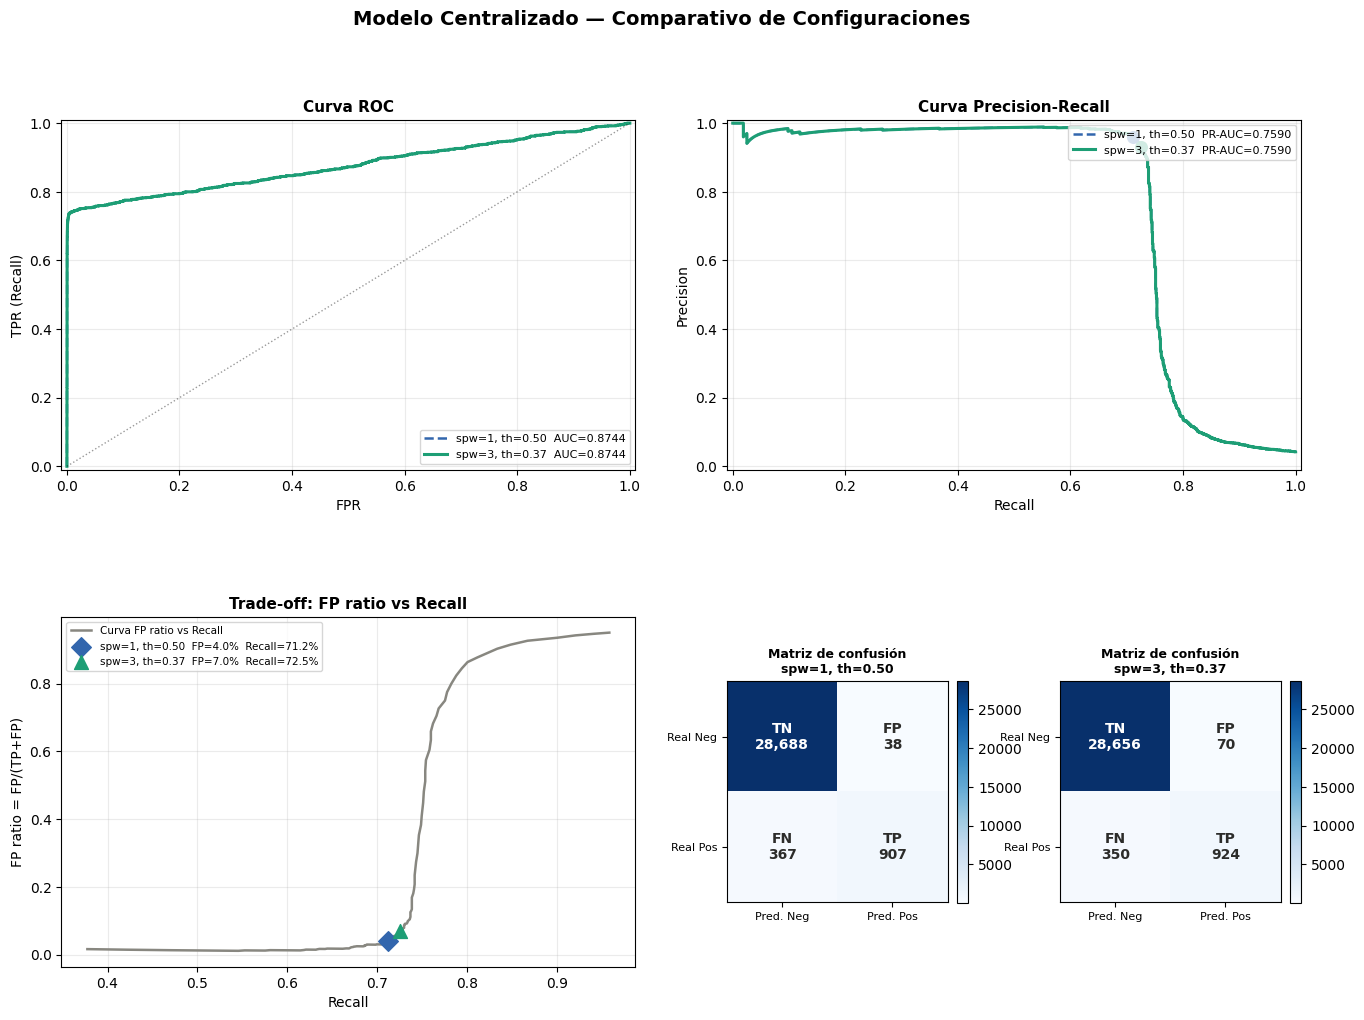

Gráfica guardada: resultados_objetivo_b/graficas_centralizado_comparativo.png



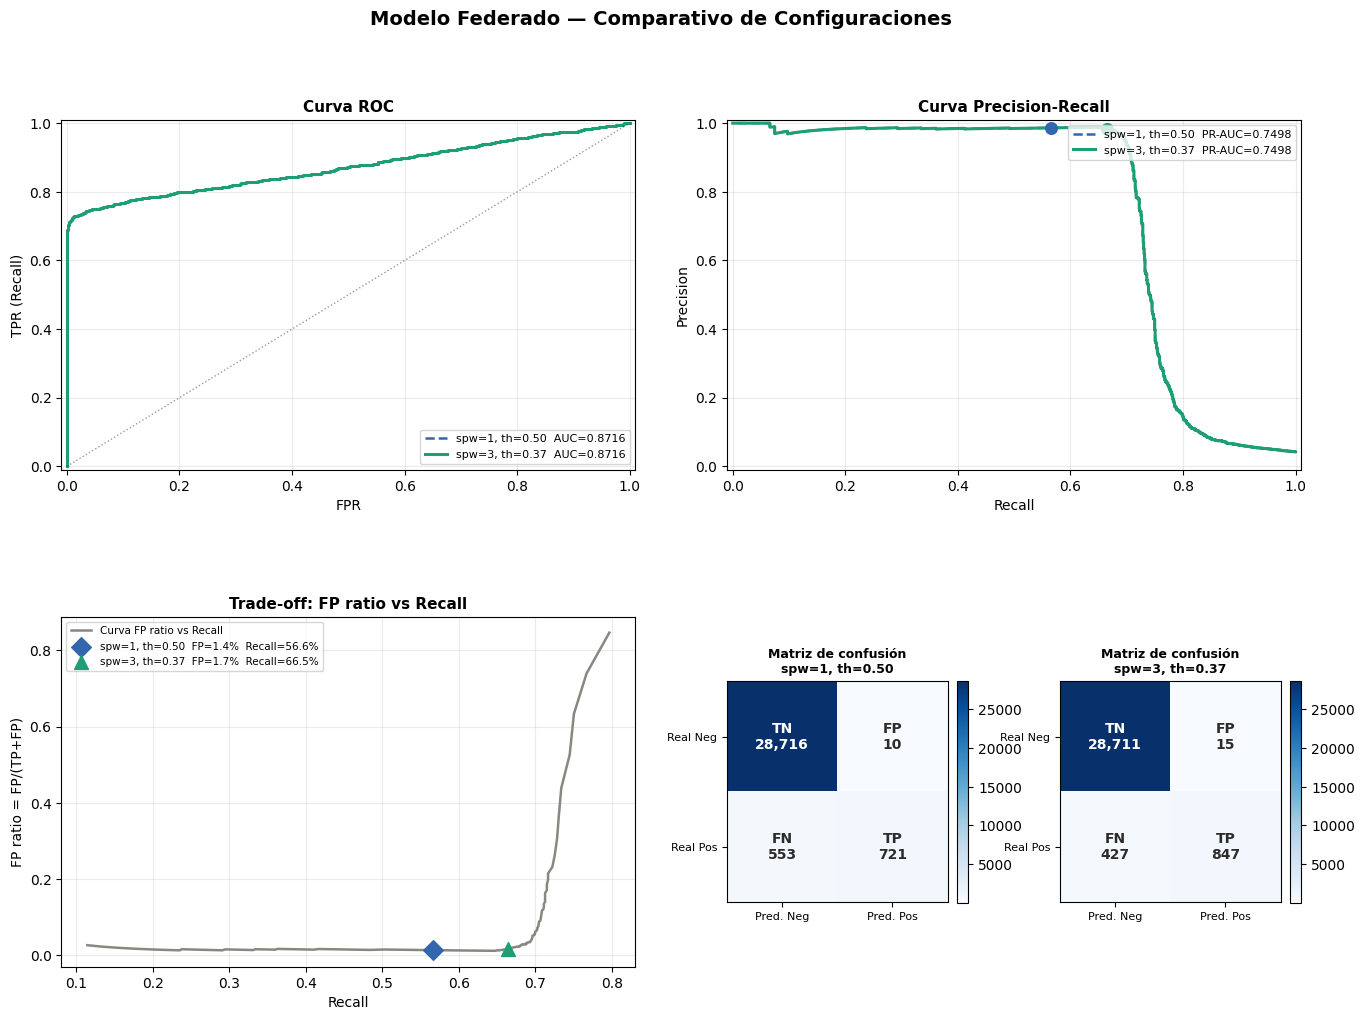

Gráfica guardada: resultados_objetivo_b/graficas_federado_comparativo.png



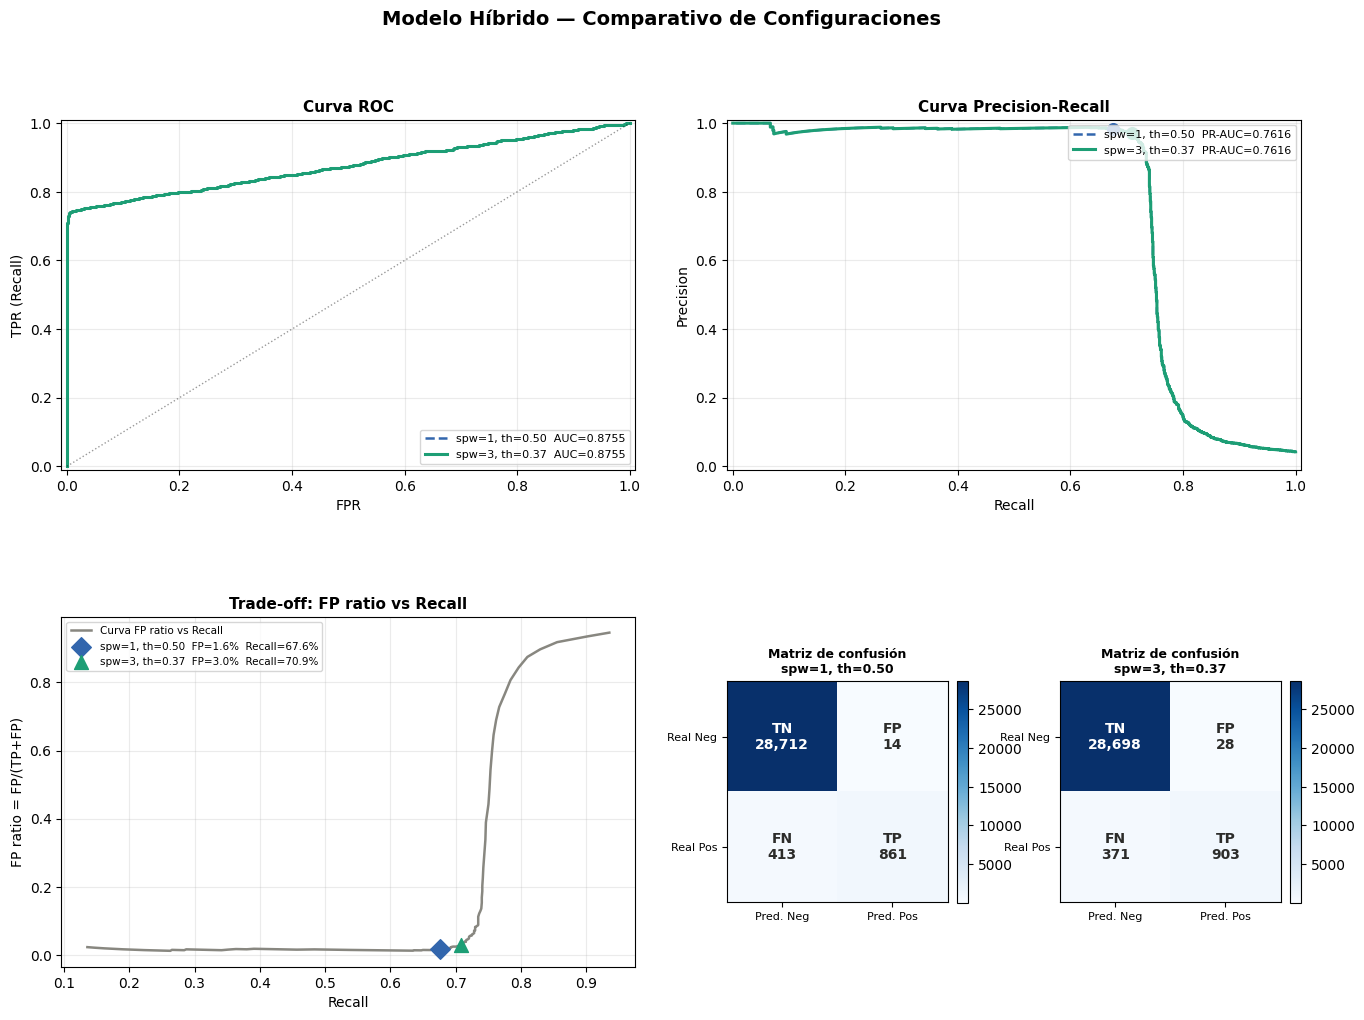

Gráfica guardada: resultados_objetivo_b/graficas_híbrido_comparativo.png



In [599]:
# ── Gráficas por modelo: ROC, PR, FP ratio vs Recall, Matrices de confusión ──
os.makedirs("resultados_objetivo_b", exist_ok=True)

COLORES = {
    "Config A  (spw=1, th=0.50)": {"color": "#3266ad", "ls": "--",  "lw": 1.8},
    "Config B  (spw=3, th=0.37)": {"color": "#1d9e75", "ls": "-",   "lw": 2.2},
}

for modelo, col in MODELOS.items():
    y_prob = df_probs[col].values[:30_000]

    fig = plt.figure(figsize=(16, 11))
    fig.suptitle(f"Modelo {modelo} — Comparativo de Configuraciones", fontsize=14, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

    ax_roc  = fig.add_subplot(gs[0, 0:2])
    ax_pr   = fig.add_subplot(gs[0, 2:4])
    ax_fp   = fig.add_subplot(gs[1, 0:2])
    axes_cm = [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]

    # ── 1. Curva ROC ─────────────────────────────────────────────
    for config, th in CONFIGS.items():
        fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        cfg = COLORES[config]
        ax_roc.plot(fpr_arr, tpr_arr,
                    color=cfg["color"], ls=cfg["ls"], lw=cfg["lw"],
                    label=f"{config.split('(')[1][:-1]}  AUC={auc_val:.4f}")

    ax_roc.plot([0,1],[0,1], "k:", lw=1, alpha=0.4)
    ax_roc.set_xlabel("FPR", fontsize=10)
    ax_roc.set_ylabel("TPR (Recall)", fontsize=10)
    ax_roc.set_title("Curva ROC", fontsize=11, fontweight="bold")
    ax_roc.legend(fontsize=8, loc="lower right")
    ax_roc.grid(True, alpha=0.25)
    ax_roc.set_xlim(-0.01, 1.01)
    ax_roc.set_ylim(-0.01, 1.01)

    # ── 2. Curva Precision-Recall ─────────────────────────────────
    for config, th in CONFIGS.items():
        prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_prob)
        pr_auc_val = average_precision_score(y_true, y_prob)
        cfg = COLORES[config]
        ax_pr.plot(rec_arr, prec_arr,
                   color=cfg["color"], ls=cfg["ls"], lw=cfg["lw"],
                   label=f"{config.split('(')[1][:-1]}  PR-AUC={pr_auc_val:.4f}")

        # Punto del threshold sobre la curva PR
        y_pred_th = (y_prob >= th).astype(int)
        tp = ((y_pred_th==1)&(y_true==1)).sum()
        fp = ((y_pred_th==1)&(y_true==0)).sum()
        fn = ((y_pred_th==0)&(y_true==1)).sum()
        p_pt = tp/(tp+fp) if (tp+fp)>0 else 0
        r_pt = tp/(tp+fn) if (tp+fn)>0 else 0
        ax_pr.scatter(r_pt, p_pt, color=cfg["color"], s=70, zorder=5, marker="o")

    ax_pr.set_xlabel("Recall", fontsize=10)
    ax_pr.set_ylabel("Precision", fontsize=10)
    ax_pr.set_title("Curva Precision-Recall", fontsize=11, fontweight="bold")
    ax_pr.legend(fontsize=8, loc="upper right")
    ax_pr.grid(True, alpha=0.25)
    ax_pr.set_xlim(-0.01, 1.01)
    ax_pr.set_ylim(-0.01, 1.01)

    # ── 3. FP ratio vs Recall (sweep de thresholds) ───────────────
    _, _, th_arr = roc_curve(y_true, y_prob)
    fp_ratios, recalls = [], []
    for t in np.linspace(0.01, 0.99, 200):
        yp = (y_prob >= t).astype(int)
        tp = int(((yp==1)&(y_true==1)).sum())
        fp = int(((yp==1)&(y_true==0)).sum())
        fn = int(((yp==0)&(y_true==1)).sum())
        r   = tp/(tp+fn) if (tp+fn)>0 else 0
        fpr = fp/(tp+fp) if (tp+fp)>0 else 0
        recalls.append(r)
        fp_ratios.append(fpr)

    ax_fp.plot(recalls, fp_ratios, color="#888780", lw=1.8, label="Curva FP ratio vs Recall")

    for config, th in CONFIGS.items():
        cfg = COLORES[config]
        row = df_metricas[(df_metricas["Modelo"]==modelo) & (df_metricas["Configuración"]==config)].iloc[0]
        ax_fp.scatter(row["Recall (%)"]/100, row["FP ratio (%)"]/100,
                      color=cfg["color"], s=100, zorder=6,
                      label=f"{config.split('(')[1][:-1]}  FP={row['FP ratio (%)']:.1f}%  Recall={row['Recall (%)']:.1f}%",
                      marker="D" if "spw=1" in config else "^")

    ax_fp.set_xlabel("Recall", fontsize=10)
    ax_fp.set_ylabel("FP ratio = FP/(TP+FP)", fontsize=10)
    ax_fp.set_title("Trade-off: FP ratio vs Recall", fontsize=11, fontweight="bold")
    ax_fp.legend(fontsize=7.5, loc="upper left")
    ax_fp.grid(True, alpha=0.25)

    # ── 4. Matrices de confusión ──────────────────────────────────
    for ax_cm, (config, th) in zip(axes_cm, CONFIGS.items()):
        y_pred_cm = (y_prob >= th).astype(int)
        cm = confusion_matrix(y_true, y_pred_cm)
        im = ax_cm.imshow(cm, cmap="Blues", interpolation="nearest")
        thresh_c = cm.max() / 2
        labels = [["TN", "FP"], ["FN", "TP"]]
        for i in range(2):
            for j in range(2):
                ax_cm.text(j, i,
                           f"{labels[i][j]}\n{cm[i,j]:,}",
                           ha="center", va="center", fontsize=10, fontweight="bold",
                           color="white" if cm[i,j] > thresh_c else "#2c2c2a")
        ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(["Pred. Neg", "Pred. Pos"], fontsize=8)
        ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(["Real Neg", "Real Pos"], fontsize=8)
        short = config.split("(")[1][:-1]
        ax_cm.set_title(f"Matriz de confusión\n{short}", fontsize=9, fontweight="bold")
        plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

    ruta_fig = f"resultados_objetivo_b/graficas_{modelo.lower()}_comparativo.png"
    plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Gráfica guardada: {ruta_fig}\n")


### Resumen de mejoras

In [600]:
# ── Resumen de mejoras Config A → Config B ───────────────────────
print("="*65)
print("RESUMEN: Config A → Config B por modelo")
print("="*65)

cols_resumen = ["Modelo", "Recall (%)", "FP ratio (%)", "F1-Score", "MCC", "TP", "FP", "FN"]
df_a_r = df_metricas[df_metricas["Configuración"].str.contains("spw=1")][cols_resumen].set_index("Modelo")
df_b_r = df_metricas[df_metricas["Configuración"].str.contains("spw=3")][cols_resumen].set_index("Modelo")

for modelo in MODELOS:
    a = df_a_r.loc[modelo]
    b = df_b_r.loc[modelo]
    delta_rec = b["Recall (%)"] - a["Recall (%)"]
    delta_fp  = b["FP ratio (%)"] - a["FP ratio (%)"]
    delta_f1  = b["F1-Score"] - a["F1-Score"]
    print(f"\n{modelo}:")
    print(f"  Recall:    {a['Recall (%)']:.2f}% → {b['Recall (%)']:.2f}%   Δ{delta_rec:+.2f}pp")
    print(f"  FP ratio:  {a['FP ratio (%)']:.2f}% → {b['FP ratio (%)']:.2f}%   Δ{delta_fp:+.2f}pp")
    print(f"  F1-Score:  {a['F1-Score']:.4f} → {b['F1-Score']:.4f}   Δ{delta_f1:+.4f}")
    print(f"  TP:        {a['TP']} → {b['TP']}   (+{b['TP']-a['TP']})")
    print(f"  FP:        {a['FP']} → {b['FP']}   (+{b['FP']-a['FP']})")
    print(f"  FN:        {a['FN']} → {b['FN']}   ({b['FN']-a['FN']})")


RESUMEN: Config A → Config B por modelo

Centralizado:
  Recall:    71.19% → 72.53%   Δ+1.34pp
  FP ratio:  4.02% → 7.04%   Δ+3.02pp
  F1-Score:  0.8175 → 0.8148   Δ-0.0027
  TP:        907.0 → 924.0   (+17.0)
  FP:        38.0 → 70.0   (+32.0)
  FN:        367.0 → 350.0   (-17.0)

Federado:
  Recall:    56.59% → 66.48%   Δ+9.89pp
  FP ratio:  1.37% → 1.74%   Δ+0.37pp
  F1-Score:  0.7192 → 0.7931   Δ+0.0739
  TP:        721.0 → 847.0   (+126.0)
  FP:        10.0 → 15.0   (+5.0)
  FN:        553.0 → 427.0   (-126.0)

Híbrido:
  Recall:    67.58% → 70.88%   Δ+3.30pp
  FP ratio:  1.60% → 3.01%   Δ+1.41pp
  F1-Score:  0.8013 → 0.8190   Δ+0.0177
  TP:        861.0 → 903.0   (+42.0)
  FP:        14.0 → 28.0   (+14.0)
  FN:        413.0 → 371.0   (-42.0)
